# 3. Scoring real companies

The ML model wins in the lab, but it was trained on Polish firms. In this notebook I point it at live Indian companies, find exactly where it breaks (it can't judge numbers outside the range it learned on), and settle on the engine that actually holds up - the linear Altman score - while keeping the ML model as the benchmark that proved the method.

Then I add the part that makes this more than a ratio calculator: four **digital signals** that read the outside world.

## Setup

The cell below defines everything used here - the Altman engine, the distress model, the four digital signals, and the combined scoring. Run it first so the analysis below has what it needs.

In [1]:
from __future__ import annotations

from pathlib import Path as _ROOTPATH
_ROOT = next((p for p in [_ROOTPATH.cwd(), *_ROOTPATH.cwd().parents]
             if (p / 'data').exists() and (p / 'models').exists()), _ROOTPATH.cwd())



"""Attribute schema for the Polish Companies Bankruptcy dataset (UCI id 365).

This module is the keystone for two things:

  * Train/serve feature parity -- the model trains on Polish `Attr1..Attr64`
    but must score Indian companies rebuilt from Screener.in financials. `serving`
    records whether each attribute is reproducible on that path.
  * Plain-English SHAP labels -- `label` is what the user sees on
    a waterfall chart. Never surface `Attr14` in the UI.

The `.arff` headers carry no definitions (verified: they are bare `@attribute AttrN
numeric`). Definitions below come from the UCI dataset documentation.

Serving availability is expressed against what Screener.in actually publishes:
  P&L         Sales, Expenses, Operating Profit, Other Income, Interest,
              Depreciation, Profit before tax, Tax%, Net Profit
  Balance     Equity Capital, Reserves, Borrowings, Other Liabilities,
              Total Liabilities, Fixed Assets, CWIP, Investments, Other Assets,
              Total Assets
  Ratios      Debtor Days, Inventory Days, Days Payable, Cash Conversion Cycle,
              Working Capital Days, ROCE%

Screener does not publish current assets / inventory / receivables as balance-sheet
line items, but they are recoverable from the days-ratios (e.g. receivables =
Debtor Days * Sales / 365). Attributes needing that reconstruction are DERIVED.
"""


from dataclasses import dataclass
from enum import Enum
from typing import Literal

TARGET = "class"
N_ATTRS = 64


class Category(str, Enum):
    """Ratio families. The first five mirror the dashboard's grouping."""

    LIQUIDITY = "Liquidity"
    SOLVENCY = "Solvency"
    PROFITABILITY = "Profitability"
    EFFICIENCY = "Efficiency"
    CASH_FLOW = "Cash Flow"
    GROWTH = "Growth"
    SIZE = "Size"


class Serving(str, Enum):
    """Can this attribute be rebuilt for an Indian company from Screener data?"""

    DIRECT = "direct"  # straight from published line items
    DERIVED = "derived"  # needs reconstruction (typically via days-ratios)
    UNAVAILABLE = "unavailable"  # not recoverable; must not enter the served model


@dataclass(frozen=True)
class Attribute:
    id: str  # "Attr1"
    formula: str  # definition as published by UCI
    label: str  # business English, shown in the UI
    category: Category
    serving: Serving


def _a(n: int, formula: str, label: str, category: Category, serving: Serving) -> Attribute:
    return Attribute(f"Attr{n}", formula, label, category, serving)


P = Category.PROFITABILITY
L = Category.LIQUIDITY
S = Category.SOLVENCY
E = Category.EFFICIENCY
C = Category.CASH_FLOW
G = Category.GROWTH
Z = Category.SIZE

D = Serving.DIRECT
V = Serving.DERIVED
U = Serving.UNAVAILABLE

ATTRIBUTES: tuple[Attribute, ...] = (
    _a(1, "net profit / total assets", "Return on Assets", P, D),
    _a(2, "total liabilities / total assets", "Debt to Assets", S, D),
    _a(3, "working capital / total assets", "Working Capital / Total Assets", L, V),
    _a(4, "current assets / short-term liabilities", "Current Ratio", L, V),
    _a(
        5,
        "[(cash + short-term securities + receivables - short-term liabilities) "
        "/ (operating expenses - depreciation)] * 365",
        "Defensive Interval (days of liquidity)",
        L,
        V,
    ),
    _a(6, "retained earnings / total assets", "Retained Earnings / Total Assets", P, D),
    _a(7, "EBIT / total assets", "Operating Return on Assets", P, D),
    _a(8, "book value of equity / total liabilities", "Equity to Debt", S, D),
    _a(9, "sales / total assets", "Asset Turnover", E, D),
    _a(10, "equity / total assets", "Equity Ratio", S, D),
    _a(
        11,
        "(gross profit + extraordinary items + financial expenses) / total assets",
        "Pre-Financing Return on Assets",
        P,
        V,
    ),
    _a(12, "gross profit / short-term liabilities", "Gross Profit / Short-Term Liabilities", P, V),
    _a(13, "(gross profit + depreciation) / sales", "Cash Gross Margin", P, V),
    _a(14, "(gross profit + interest) / total assets", "Pre-Interest Return on Assets", P, V),
    _a(
        15,
        "(total liabilities * 365) / (gross profit + depreciation)",
        "Debt Repayment Period (days)",
        S,
        V,
    ),
    _a(16, "(gross profit + depreciation) / total liabilities", "Cash Flow to Debt", C, V),
    _a(17, "total assets / total liabilities", "Asset Coverage of Debt", S, D),
    _a(18, "gross profit / total assets", "Gross Return on Assets", P, V),
    _a(19, "gross profit / sales", "Gross Margin", P, V),
    _a(20, "(inventory * 365) / sales", "Inventory Days", E, D),
    _a(21, "sales (n) / sales (n-1)", "Sales Growth (year on year)", G, D),
    _a(22, "profit on operating activities / total assets", "Operating Profit / Total Assets", P, D),
    _a(23, "net profit / sales", "Net Profit Margin", P, D),
    _a(24, "gross profit (in 3 years) / total assets", "3-Year Gross Profit / Total Assets", P, V),
    _a(25, "(equity - share capital) / total assets", "Reserves / Total Assets", S, D),
    _a(26, "(net profit + depreciation) / total liabilities", "Cash Earnings to Debt", C, D),
    _a(27, "profit on operating activities / financial expenses", "Interest Coverage Ratio", S, D),
    _a(28, "working capital / fixed assets", "Working Capital / Fixed Assets", L, V),
    _a(29, "logarithm of total assets", "Company Size (log total assets)", Z, D),
    _a(30, "(total liabilities - cash) / sales", "Net Debt to Sales", S, V),
    _a(31, "(gross profit + interest) / sales", "Pre-Interest Margin", P, V),
    _a(32, "(current liabilities * 365) / cost of products sold", "Payable Days", E, V),
    _a(33, "operating expenses / short-term liabilities", "Operating Expenses / Short-Term Liabilities", E, V),
    _a(34, "operating expenses / total liabilities", "Operating Expenses / Total Liabilities", E, V),
    _a(35, "profit on sales / total assets", "Sales Profit / Total Assets", P, V),
    _a(36, "total sales / total assets", "Total Asset Turnover", E, D),
    _a(37, "(current assets - inventories) / long-term liabilities", "Quick Assets / Long-Term Debt", L, V),
    _a(38, "constant capital / total assets", "Permanent Capital / Total Assets", S, V),
    _a(39, "profit on sales / sales", "Sales Profit Margin", P, V),
    _a(
        40,
        "(current assets - inventory - receivables) / short-term liabilities",
        "Cash Ratio",
        L,
        V,
    ),
    _a(41, "total liabilities / ((profit on operating activities + depreciation) * (12/365))", "Debt to Annualised Operating Cash Flow", S, V),
    _a(42, "profit on operating activities / sales", "Operating Margin", P, D),
    _a(43, "rotation receivables + inventory turnover in days", "Cash Conversion Days", E, D),
    _a(44, "(receivables * 365) / sales", "Receivable Days", E, D),
    _a(45, "net profit / inventory", "Net Profit / Inventory", E, V),
    _a(46, "(current assets - inventory) / short-term liabilities", "Quick Ratio", L, V),
    _a(47, "(inventory * 365) / cost of products sold", "Inventory Days (on cost)", E, V),
    _a(48, "EBITDA / total assets", "EBITDA Return on Assets", P, D),
    _a(49, "EBITDA / sales", "EBITDA Margin", P, D),
    _a(50, "current assets / total liabilities", "Current Assets / Total Debt", L, V),
    _a(51, "short-term liabilities / total assets", "Short-Term Debt / Total Assets", S, V),
    _a(52, "(short-term liabilities * 365) / cost of products sold", "Short-Term Debt Coverage (days of cost)", E, V),
    _a(53, "equity / fixed assets", "Equity / Fixed Assets", S, D),
    _a(54, "constant capital / fixed assets", "Permanent Capital / Fixed Assets", S, V),
    _a(55, "working capital", "Working Capital (absolute)", L, V),
    _a(56, "(sales - cost of products sold) / sales", "Gross Margin on Cost", P, V),
    _a(
        57,
        "(current assets - inventory - short-term liabilities) "
        "/ (sales - gross profit - depreciation)",
        "Net Quick Assets / Cash Costs",
        L,
        V,
    ),
    _a(58, "total costs / total sales", "Cost to Sales Ratio", E, D),
    _a(59, "long-term liabilities / equity", "Long-Term Debt to Equity", S, V),
    _a(60, "sales / inventory", "Inventory Turnover", E, V),
    _a(61, "sales / receivables", "Receivables Turnover", E, D),
    _a(62, "(short-term liabilities * 365) / sales", "Short-Term Debt Days", E, V),
    _a(63, "sales / short-term liabilities", "Sales / Short-Term Liabilities", E, V),
    _a(64, "sales / fixed assets", "Fixed Asset Turnover", E, D),
)

BY_ID: dict[str, Attribute] = {a.id: a for a in ATTRIBUTES}

#: SHAP/plot rename map. Use everywhere a feature name reaches a chart or the UI.
LABELS: dict[str, str] = {a.id: a.label for a in ATTRIBUTES}

#: Attribute 55 is an absolute currency amount, not a ratio. It does not transfer
#: across economies (PLN balance sheets vs INR) and is excluded from the served
#: feature set for scale reasons even though it is technically reconstructible.
SCALE_DEPENDENT: frozenset[str] = frozenset({"Attr55"})


def label_for(attr_id: str) -> str:
    """Business-English label for a feature id, falling back to the id itself."""
    return LABELS.get(attr_id, attr_id)


def rename_for_display(names) -> list[str]:
    """Map a sequence of feature ids to display labels (for SHAP plots)."""
    return [label_for(n) for n in names]


def by_category(category: Category) -> tuple[Attribute, ...]:
    return tuple(a for a in ATTRIBUTES if a.category is category)


def serving_feature_set(include_derived: bool = True) -> tuple[str, ...]:
    """Attributes usable by a model that must also score Indian companies.

    This is the feature-parity guard. Training on the full 64 yields a model that cannot
    score the demo companies at all -- a different feature space. Pass
    ``include_derived=False`` for the conservative subset that needs no
    days-ratio reconstruction.
    """
    allowed = {Serving.DIRECT} | ({Serving.DERIVED} if include_derived else set())
    return tuple(
        a.id
        for a in ATTRIBUTES
        if a.serving in allowed and a.id not in SCALE_DEPENDENT
    )


def coverage_summary() -> dict[str, int]:
    """Counts per serving class, for the model card and README."""
    out = {s.value: 0 for s in Serving}
    for a in ATTRIBUTES:
        out[a.serving.value] += 1
    return out


# --------------------------------------------------------------------------------
# Economic direction, for monotonic model constraints.
# --------------------------------------------------------------------------------
# Sign convention matches XGBoost/LightGBM `monotone_constraints`, expressed against
# the model output P(distress):
#
#   -1  higher feature value -> LOWER distress probability   (e.g. interest coverage)
#   +1  higher feature value -> HIGHER distress probability  (e.g. debt / assets)
#    0  unconstrained
#
# We constrain only where the economics are unambiguous. Ratios whose direction is
# genuinely industry-dependent are left at 0 rather than guessed: a wrong constraint
# is worse than no constraint, because it forces the model to encode false economics
# and cannot be detected by looking at the score.
#
# Deliberately left UNCONSTRAINED, with reasons:
#   * Turnover ratios (Attr9, 36, 60, 61, 64) -- asset intensity is a sector fact, not
#     a health fact. A utility and a software firm sit at opposite ends while both
#     being solvent.
#   * Days ratios (Attr20, 32, 43, 44, 47, 52, 62) -- extremes are bad in both
#     directions, and normal ranges differ by orders of magnitude across sectors.
#   * Attr21 sales growth -- decline signals distress, but so does hypergrowth. Byju's
#     is in our own demo set precisely as a growth-then-collapse case, so constraining
#     "more growth = safer" would contradict a case study we intend to show.
#   * Attr29 company size -- large firms fail too. IL&FS was among the largest NBFCs
#     in India when it collapsed.

class Direction(int, Enum):
    RISK_DECREASING = -1
    UNCONSTRAINED = 0
    RISK_INCREASING = 1


_RISK_DECREASING = {
    # Profitability -- more profit is unambiguously safer.
    1, 6, 7, 11, 12, 13, 14, 18, 19, 22, 23, 24, 31, 35, 39, 42, 48, 49, 56,
    # Liquidity -- more cover for near-term obligations is safer.
    3, 4, 5, 28, 37, 40, 46, 50, 55, 57,
    # Solvency / capital structure -- more equity and asset cover is safer.
    8, 10, 17, 25, 38, 53, 54,
    # Cash flow / debt service -- more cash per unit of debt is safer.
    16, 26, 27,
}

_RISK_INCREASING = {
    2,   # total liabilities / total assets
    15,  # debt repayment period (days)
    30,  # net debt / sales
    41,  # debt / annualised operating cash flow
    51,  # short-term liabilities / total assets
    58,  # total costs / total sales
    59,  # long-term liabilities / equity
}

DIRECTIONS: dict[str, Direction] = {
    f"Attr{i}": (
        Direction.RISK_DECREASING
        if i in _RISK_DECREASING
        else Direction.RISK_INCREASING
        if i in _RISK_INCREASING
        else Direction.UNCONSTRAINED
    )
    for i in range(1, N_ATTRS + 1)
}


#: Metrics exposed to the user as sliders, cards, or what-if inputs.
#:
#: Monotonicity is fundamentally a **UI guarantee**, not a global modelling goal: it
#: matters for a metric precisely when a user can move it and watch the score respond.
#: Constraining only these ten costs 0.023 PR-AUC; constraining all 45 directional
#: attributes costs 0.10 for no additional demo safety. Scope the constraint to the
#: surface the user can actually touch.
#:
#: **Anything added to a what-if or stress slider must be added here**,
#: or that control can move the score the wrong way on stage.
SLIDER_FEATURES: tuple[str, ...] = (
    "Attr27",  # Interest Coverage Ratio
    "Attr2",   # Debt to Assets
    "Attr4",   # Current Ratio
    "Attr46",  # Quick Ratio
    "Attr1",   # Return on Assets
    "Attr23",  # Net Profit Margin
    "Attr10",  # Equity Ratio
    "Attr59",  # Long-Term Debt to Equity
    "Attr7",   # Operating Return on Assets
    "Attr17",  # Asset Coverage of Debt
)

Scope = Literal["slider", "all", "none"]


def direction_for(attr_id: str) -> Direction:
    return DIRECTIONS.get(attr_id, Direction.UNCONSTRAINED)


def monotone_vector(features, scope: Scope = "slider") -> tuple[int, ...]:
    """Constraint vector aligned to `features`, for `monotone_constraints`.

    **Order is load-bearing.** Both boosters match this vector positionally against the
    training matrix, so it must be built from the exact feature list passed to `fit`.
    A misaligned vector applies the wrong constraint to the wrong ratio and fails
    silently -- the model still trains, it just encodes nonsense.

    `scope="slider"` (default) constrains only user-facing metrics -- the measured best
    trade. `"all"` constrains every directional attribute; `"none"` disables.
    """
    if scope == "none":
        return tuple(0 for _ in features)
    if scope == "all":
        return tuple(int(direction_for(f)) for f in features)
    if scope == "slider":
        return tuple(
            int(direction_for(f)) if f in SLIDER_FEATURES else 0 for f in features
        )
    raise ValueError(f"scope must be 'slider', 'all', or 'none'; got {scope!r}")


def constraint_summary() -> dict[str, int]:
    counts = {d.name.lower(): 0 for d in Direction}
    for d in DIRECTIONS.values():
        counts[d.name.lower()] += 1
    return counts


def validate_schema() -> None:
    """Fail loudly if the schema drifts from the dataset's real shape."""
    if len(ATTRIBUTES) != N_ATTRS:
        raise ValueError(f"expected {N_ATTRS} attributes, found {len(ATTRIBUTES)}")

    overlap = _RISK_DECREASING & _RISK_INCREASING
    if overlap:
        raise ValueError(f"attributes given contradictory directions: {sorted(overlap)}")

    stray = (_RISK_DECREASING | _RISK_INCREASING) - set(range(1, N_ATTRS + 1))
    if stray:
        raise ValueError(f"direction assigned to non-existent attributes: {sorted(stray)}")

    # A slider metric with no direction would be silently left unconstrained -- the
    # exact failure this whole mechanism exists to prevent.
    undirected = [f for f in SLIDER_FEATURES if DIRECTIONS.get(f) is Direction.UNCONSTRAINED]
    if undirected:
        raise ValueError(f"slider features lack an economic direction: {undirected}")

    unserved = [f for f in SLIDER_FEATURES if f not in serving_feature_set()]
    if unserved:
        raise ValueError(f"slider features not in the serving set: {unserved}")

    expected = [f"Attr{i}" for i in range(1, N_ATTRS + 1)]
    actual = [a.id for a in ATTRIBUTES]
    if actual != expected:
        missing = set(expected) - set(actual)
        raise ValueError(f"attribute ids not contiguous 1..64; missing={sorted(missing)}")

    if len(set(LABELS.values())) != N_ATTRS:
        seen: dict[str, str] = {}
        for a in ATTRIBUTES:
            if a.label in seen:
                raise ValueError(f"duplicate label {a.label!r}: {seen[a.label]} and {a.id}")
            seen[a.label] = a.id


validate_schema()

"""Loader for the Polish Companies Bankruptcy `.arff` files.

The files are ARFF with `?` for missing values and a `{0,1}` nominal target. We parse
them directly rather than depending on `scipy.io.arff`, which returns the target as
bytes and chokes on some of the malformed numeric fields in this dataset.

Horizon semantics matter for the story: `1year.arff` means "bankrupt within 1 year of
the reported financials" -- the shortest, hardest-to-act-on warning. `5year.arff` is
the earliest signal. Foresight AI is about early warning, so the longer horizons are
not throwaways; they are the point.
"""


from pathlib import Path

import numpy as np
import pandas as pd


RAW_DIR = _ROOT / "data" / "raw"
HORIZONS = (1, 2, 3, 4, 5)


def _arff_path(horizon: int) -> Path:
    if horizon not in HORIZONS:
        raise ValueError(f"horizon must be one of {HORIZONS}, got {horizon}")
    return RAW_DIR / f"{horizon}year.arff"


def load_horizon(horizon: int, raw_dir: Path | None = None) -> pd.DataFrame:
    """Load one forecasting horizon into a DataFrame.

    Returns columns `Attr1..Attr64` as float64 (missing as NaN) plus an int8 `class`.
    A `horizon` column is attached so stacked frames stay traceable.
    """
    path = _arff_path(horizon) if raw_dir is None else Path(raw_dir) / f"{horizon}year.arff"
    if not path.exists():
        raise FileNotFoundError(
            f"{path} not found. Download the dataset from UCI id 365 into {path.parent}."
        )

    rows: list[list[str]] = []
    in_data = False
    with path.open(encoding="utf-8", errors="replace") as fh:
        for line in fh:
            line = line.strip()
            if not in_data:
                if line.lower().startswith("@data"):
                    in_data = True
                continue
            if not line or line.startswith("%"):
                continue
            rows.append(line.split(","))

    if not rows:
        raise ValueError(f"no data rows parsed from {path}")

    width = N_ATTRS + 1
    bad = [i for i, r in enumerate(rows) if len(r) != width]
    if bad:
        raise ValueError(
            f"{path.name}: {len(bad)} rows have wrong field count "
            f"(expected {width}); first at data row {bad[0]}"
        )

    columns = [f"Attr{i}" for i in range(1, N_ATTRS + 1)] + [TARGET]
    df = pd.DataFrame(rows, columns=columns)
    df = df.replace({"?": np.nan, "": np.nan})
    df = df.astype("float64")

    if not df[TARGET].dropna().isin({0.0, 1.0}).all():
        raise ValueError(f"{path.name}: target contains values outside {{0,1}}")

    df[TARGET] = df[TARGET].astype("int8")
    df.insert(0, "horizon", np.int8(horizon))
    return df


def load_all(raw_dir: Path | None = None) -> pd.DataFrame:
    """Stack all five horizons.

    Note: a company may appear across multiple horizon files. Any cross-horizon
    modelling must group by company to avoid leakage -- but the dataset ships no
    company identifier, so horizons are modelled separately by default.
    """
    return pd.concat(
        [load_horizon(h, raw_dir) for h in HORIZONS], ignore_index=True
    )


def class_balance(df: pd.DataFrame) -> dict[str, float]:
    """Distress rate and counts -- the numbers that justify banning accuracy."""
    counts = df[TARGET].value_counts()
    n = int(len(df))
    distress = int(counts.get(1, 0))
    return {
        "n": n,
        "distress": distress,
        "healthy": int(counts.get(0, 0)),
        "distress_rate": round(distress / n, 5) if n else 0.0,
        "majority_baseline_accuracy": round((n - distress) / n, 5) if n else 0.0,
    }


def missingness(df: pd.DataFrame) -> pd.Series:
    """Fraction missing per attribute, descending. Attr37 is the known worst offender."""
    attrs = [c for c in df.columns if c.startswith("Attr")]
    return df[attrs].isna().mean().sort_values(ascending=False)

"""Altman Z-Score, computed on the correct variant for this dataset.

The textbook thresholds 1.81 / 2.99 belong to the
**original 1968 Z**, whose X4 term is *market* value of equity / total liabilities.
The Polish companies are effectively private -- there is no market capitalisation in
the data, and `Attr8` is explicitly *book* value of equity / total liabilities. Using
book equity with original-Z cutoffs would silently mis-band every company.

We therefore implement the two private-firm revisions and default to Z'':

    Z'  (1983, private manufacturing, 5 variables)
        0.717 X1 + 0.847 X2 + 3.107 X3 + 0.420 X4 + 0.998 X5
        distress < 1.23        grey 1.23-2.90      safe > 2.90

    Z'' (1995, private, non-manufacturer-neutral, 4 variables; drops sales/TA)
        6.56 X1 + 3.26 X2 + 6.72 X3 + 1.05 X4
        distress < 1.10        grey 1.10-2.60      safe > 2.60

Z'' is the default because the Polish dataset spans sectors and Z'' deliberately drops
the asset-turnover term that makes Z' industry-sensitive.

Component mapping to the dataset (exact, no proxies needed):

    X1 working capital / total assets            Attr3
    X2 retained earnings / total assets          Attr6
    X3 EBIT / total assets                       Attr7
    X4 book value of equity / total liabilities  Attr8
    X5 sales / total assets                      Attr9   (Z' only)

We use Z-double-prime, the private-firm variant, because these are unlisted companies
with no market value of equity. Its published 1.1 and 2.6 cutoffs replace the original
1.81 and 2.99, which only apply to the market-value formulation.
"""


from dataclasses import dataclass
from typing import Literal

import numpy as np
import pandas as pd

Variant = Literal["z2", "zprime"]

ZONE_DISTRESS = "Distress"
ZONE_GREY = "Grey"
ZONE_SAFE = "Safe"

#: Three-class distress labels. Ordered worst to best.
CLASS_DISTRESS = "distress"
CLASS_WATCH = "watch"
CLASS_HEALTHY = "healthy"


@dataclass(frozen=True)
class ZSpec:
    name: str
    coefficients: dict[str, float]
    distress_below: float
    safe_above: float
    description: str


Z_DOUBLE_PRIME = ZSpec(
    name="Z''",
    coefficients={"Attr3": 6.56, "Attr6": 3.26, "Attr7": 6.72, "Attr8": 1.05},
    distress_below=1.10,
    safe_above=2.60,
    description="Altman Z'' (1995) - private firms, sector-neutral, book equity",
)

Z_PRIME = ZSpec(
    name="Z'",
    coefficients={
        "Attr3": 0.717,
        "Attr6": 0.847,
        "Attr7": 3.107,
        "Attr8": 0.420,
        "Attr9": 0.998,
    },
    distress_below=1.23,
    safe_above=2.90,
    description="Altman Z' (1983) - private manufacturing, book equity",
)

SPECS: dict[str, ZSpec] = {"z2": Z_DOUBLE_PRIME, "zprime": Z_PRIME}


def get_spec(variant: Variant = "z2") -> ZSpec:
    try:
        return SPECS[variant]
    except KeyError:
        raise ValueError(f"variant must be one of {sorted(SPECS)}, got {variant!r}") from None


def altman_z(df: pd.DataFrame, variant: Variant = "z2") -> pd.Series:
    """Compute the Altman Z-Score for each row.

    Rows missing any component yield NaN rather than a partial score -- a Z built from
    three of four terms is not a Z, and quietly zero-filling would push companies
    toward the distress band for a data reason rather than a financial one.
    """
    spec = get_spec(variant)
    missing = [c for c in spec.coefficients if c not in df.columns]
    if missing:
        raise KeyError(f"{spec.name} requires missing columns: {missing}")

    components = df[list(spec.coefficients)].astype("float64")
    # A row with any NaN component must not produce a score.
    valid = components.notna().all(axis=1)

    weights = pd.Series(spec.coefficients, dtype="float64")
    z = components.mul(weights, axis=1).sum(axis=1)
    z = z.where(valid, np.nan)
    z.name = f"altman_{variant}"
    return z


def zone(z: pd.Series, variant: Variant = "z2") -> pd.Series:
    """Band a Z-Score series into Distress / Grey / Safe."""
    spec = get_spec(variant)
    out = pd.Series(pd.NA, index=z.index, dtype="object")
    out[z < spec.distress_below] = ZONE_DISTRESS
    out[(z >= spec.distress_below) & (z <= spec.safe_above)] = ZONE_GREY
    out[z > spec.safe_above] = ZONE_SAFE
    out.name = "altman_zone"
    return out


def three_class_label(
    df: pd.DataFrame,
    variant: Variant = "z2",
    target: str = "class",
) -> pd.Series:
    """Nuanced distress label: healthy / watch / distress.

    the design calls for three classes rather than binary bankruptcy, because banks
    think in watchlists, not binary outcomes. The rule is deliberately conservative:

      * an actual bankruptcy in the dataset is always `distress` -- the ground-truth
        label outranks the ratio-based heuristic and is never softened;
      * a surviving company in the Z distress or grey band is `watch`;
      * everything else is `healthy`.

    Companies with no computable Z fall back to their binary label so the column is
    never NaN for a row we intend to train on.
    """
    z = altman_z(df, variant)
    bands = zone(z, variant)

    label = pd.Series(CLASS_HEALTHY, index=df.index, dtype="object")
    label[bands.isin({ZONE_DISTRESS, ZONE_GREY})] = CLASS_WATCH

    if target in df.columns:
        label[df[target] == 1] = CLASS_DISTRESS

    label.name = "distress_class"
    return label


def attach(
    df: pd.DataFrame,
    variant: Variant = "z2",
    target: str = "class",
) -> pd.DataFrame:
    """Return a copy with Z-Score, zone, and three-class label attached."""
    out = df.copy()
    out[f"altman_{variant}"] = altman_z(df, variant)
    out["altman_zone"] = zone(out[f"altman_{variant}"], variant)
    out["distress_class"] = three_class_label(df, variant, target)
    return out


def benchmark_vs_truth(df: pd.DataFrame, variant: Variant = "z2", target: str = "class") -> dict:
    """How well does the classical Z alone separate the real bankruptcies?

    This is the number the ML model has to beat. Showing it explicitly is the point of
    the "show both" requirement -- the panel shows what the ML adds over the
    textbook benchmark.
    """
    z = altman_z(df, variant)
    spec = get_spec(variant)
    ok = z.notna() & df[target].notna()
    if not ok.any():
        return {"variant": spec.name, "scored": 0}

    flagged = z[ok] < spec.distress_below
    truth = df.loc[ok, target] == 1

    tp = int((flagged & truth).sum())
    fp = int((flagged & ~truth).sum())
    fn = int((~flagged & truth).sum())

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0

    return {
        "variant": spec.name,
        "scored": int(ok.sum()),
        "unscored_missing_components": int((~z.notna()).sum()),
        "flagged_distress": int(flagged.sum()),
        "true_distress": int(truth.sum()),
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "f1": round(2 * precision * recall / (precision + recall), 4)
        if (precision + recall)
        else 0.0,
    }


"""Shared data model for the four Digital Pulse signals.

Design decisions locked in here:

* **Same 0-100 risk scale and band language as the financial score.** Higher = worse,
  bands Healthy / Watch / Elevated Risk / Critical. This is what makes fusion a
  plain weighted average later -- financial and digital scores speak one language.

* **Every reading carries a specific explanatory datum**, not a restated metric. Not
  "Sentiment: negative" but "Sentiment declining for 11 weeks;
  68% of coverage mentions 'liquidity concerns'." The datum is a required field.

* **Time-series, not snapshot.** A signal is observed at multiple dates. The latest
  reading feeds the gauges; the trajectory feeds the case-study timeline.
  `SignalSeries` holds the history; `.latest()` is what the gauge shows.

* **Trend is first-class**, computed from the series, because for these signals the
  direction matters more than the level (a company going 300 -> 80 job postings is the
  signal, not the absolute 80).
"""


from dataclasses import dataclass, field
from datetime import date
from enum import Enum
from typing import Optional


class SignalKind(str, Enum):
    NEWS_SENTIMENT = "News Sentiment"
    LEADERSHIP = "Leadership Stability"
    HIRING = "Hiring Activity"
    EMPLOYEE = "Employee Confidence"


class Trend(str, Enum):
    """Direction of travel. Worsening is what a risk desk cares about."""

    IMPROVING = "Improving"
    STABLE = "Stable"
    DETERIORATING = "Deteriorating"


# Reuse the single band definition from the serving financial score so the digital
# gauges and the financial gauge cannot drift apart.
def band_for(risk: float) -> str:
    _bf = band_for

    return _bf(risk)


@dataclass(frozen=True)
class SignalReading:
    """One signal, observed at one date, on the shared risk scale."""

    kind: SignalKind
    as_of: date
    risk_score: float          # 0-100, higher = worse
    label: str                 # signal-specific status, e.g. "Contracting"
    datum: str                 # the specific explanatory sentence (required)
    raw: float = 0.0           # underlying measure (sentiment, exit count, ...)
    #: True for a verified hard event -- a tribunal displacing the board, an auditor
    #: resigning. These are *facts*, not inferences, and must not be averaged away by
    #: softer signals (see `composite.combine`). News tone in particular runs the wrong
    #: way on legal process: "NCLAT stays insolvency admission" reads +0.69 positive to
    #: FinBERT while describing a company in insolvency.
    hard_event: bool = False

    @property
    def band(self) -> str:
        return band_for(self.risk_score)


@dataclass
class SignalSeries:
    """A signal's full observed history for one company."""

    kind: SignalKind
    company: str
    readings: list[SignalReading] = field(default_factory=list)

    def __post_init__(self) -> None:
        self.readings.sort(key=lambda r: r.as_of)

    def latest(self) -> Optional[SignalReading]:
        return self.readings[-1] if self.readings else None

    def as_of(self, when: date) -> Optional[SignalReading]:
        """Point-in-time accessor: the most recent reading at or before `when`.

        This is the Trap-3 guard -- scoring a company as of a past date must never see a
        reading published after it.
        """
        eligible = [r for r in self.readings if r.as_of <= when]
        return eligible[-1] if eligible else None

    def trend(self, window: int = 2) -> Trend:
        """Direction over the last `window` readings, on the risk scale."""
        if len(self.readings) < 2:
            return Trend.STABLE
        recent = self.readings[-window:]
        delta = recent[-1].risk_score - recent[0].risk_score
        if delta > 5:
            return Trend.DETERIORATING
        if delta < -5:
            return Trend.IMPROVING
        return Trend.STABLE


def clamp_score(x: float) -> float:
    return float(min(max(x, 0.0), 100.0))

"""Hiring Activity signal (soft).

Active job-posting count over time (Naukri-style). The
*trend* matters more than the absolute -- a company going 300 -> 80 postings is signalling
contraction regardless of its size. Historical posting counts cannot be scraped after the
fact, so the demo data is illustrative and labelled as such (same basis as Glassdoor).

Point-in-time via `hiring_score_as_of`: only counts observed on or before `when` are used.
"""


from dataclasses import dataclass
from datetime import date



@dataclass(frozen=True)
class HiringObservation:
    observed: date
    active_postings: int


def _pct_change(latest: int, baseline: int) -> float:
    if baseline == 0:
        return 0.0
    return (latest - baseline) / baseline


def hiring_score_as_of(
    observations: list[HiringObservation],
    when: date,
    company: str = "",
) -> SignalReading:
    """Hiring reading as of `when`, from the trend across prior observations."""
    hist = sorted([o for o in observations if o.observed <= when], key=lambda o: o.observed)
    if not hist:
        return SignalReading(
            kind=SignalKind.HIRING, as_of=when, risk_score=40.0,
            label="No data", datum="No hiring data available.", raw=0.0,
        )

    latest = hist[-1]
    baseline = hist[0]
    change = _pct_change(latest.active_postings, baseline.active_postings)

    # Contraction raises risk; expansion lowers it. Anchored so a ~60% contraction lands
    # Elevated and steady/growing hiring lands Healthy.
    risk = clamp_score(35.0 - 200.0 * change)

    if change <= -0.08:
        label = "Contracting"
    elif change >= 0.05:
        label = "Growing"
    else:
        label = "Stable"

    datum = (
        f"Headcount {baseline.active_postings:,} -> {latest.active_postings:,} "
        f"({change:+.0%}) since {baseline.observed.isoformat()}."
    )
    return SignalReading(
        kind=SignalKind.HIRING, as_of=when, risk_score=risk,
        label=label, datum=datum, raw=float(latest.active_postings),
    )

"""Leadership Stability signal from BSE-style corporate filings (anchor).

This is the hardest-evidence of the four signals, and it is
uniquely India-specific: every board-level change, KMP resignation, and auditor change
must be filed with the exchange, dated and public. There is **no selection-bias risk** --
a resignation happened on its filing date or it did not. That makes this the anchor the
softer signals lean on.

The signal is the count of *senior* departures in a trailing window (default 6 months),
weighted by seniority: a CFO or auditor walking out is a sharper distress tell than an
independent director rotating off. More than two senior exits in the window is the red
line, and it maps to the Elevated/Critical threshold.

Point-in-time is intrinsic: `leadership_score_as_of(when)` only counts events filed on or before
`when`, so a 2019 assessment never sees a 2020 filing.
"""


from dataclasses import dataclass
from datetime import date, timedelta
from enum import Enum



class Role(str, Enum):
    CEO = "CEO"
    CFO = "CFO"
    MD = "Managing Director"
    CHAIRMAN = "Chairman"
    FOUNDER = "Founder"
    AUDITOR = "Auditor"
    COMPANY_SECRETARY = "Company Secretary"
    WHOLETIME_DIRECTOR = "Whole-Time Director"
    INDEPENDENT_DIRECTOR = "Independent Director"
    BOARD = "Board of Directors"


class EventType(str, Enum):
    RESIGNATION = "resignation"
    APPOINTMENT = "appointment"
    AUDITOR_EXIT = "auditor exit"
    #: Insolvency admission vesting the board's powers in a resolution professional.
    #: The most severe governance event there is -- the board stops governing.
    BOARD_SUSPENSION = "board powers suspended"


#: Seniority weights. A departure's contribution to the risk score. Auditor and CFO
#: exits are weighted highest -- in Indian corporate collapses (IL&FS, many NBFCs) an
#: auditor walking out preceded the public crisis.
_EXIT_WEIGHT: dict[Role, float] = {
    Role.BOARD: 5.0,   # whole board displaced by a resolution professional
    Role.AUDITOR: 2.0,
    Role.CFO: 1.8,
    Role.CEO: 1.6,
    Role.MD: 1.6,
    Role.FOUNDER: 1.5,
    Role.CHAIRMAN: 1.4,
    Role.WHOLETIME_DIRECTOR: 1.1,
    Role.COMPANY_SECRETARY: 0.9,
    Role.INDEPENDENT_DIRECTOR: 0.8,
}

# Points per unit of weighted-exit, tuned so "> 2 exits = red" lands in
# the Elevated band: two average senior exits (weight ~1.5 each = 3.0) -> ~54.
_POINTS_PER_WEIGHT = 18.0
_BASELINE = 6.0  # a stable company still shows minor churn


@dataclass(frozen=True)
class LeadershipEvent:
    company: str
    filing_date: date
    role: Role
    person: str
    event_type: EventType
    #: True only for events confirmed against a real, dated public filing. The anchor's
    #: whole value ("a resignation happened on its date or it did not") depends
    #: on this being real -- an unverified stand-in must not be presented as a filing.
    verified: bool = True

    @property
    def is_exit(self) -> bool:
        return self.event_type in (
            EventType.RESIGNATION, EventType.AUDITOR_EXIT, EventType.BOARD_SUSPENSION)


def _window_exits(
    events: list[LeadershipEvent], when: date, months: int
) -> list[LeadershipEvent]:
    start = when - timedelta(days=int(months * 30.44))
    return [
        e for e in events
        if e.is_exit and start <= e.filing_date <= when
    ]


def _describe(exits: list[LeadershipEvent], months: int) -> str:
    """The specific explanatory datum -- who left, not just how many."""
    if not exits:
        return f"No senior departures filed in the last {months} months."

    # A board suspension is not a "departure" -- describe it as what it is.
    suspensions = [e for e in exits if e.event_type is EventType.BOARD_SUSPENSION]
    if suspensions:
        others = len(exits) - len(suspensions)
        extra = f" Also {others} senior departure{'s' if others > 1 else ''} in the period." if others else ""
        d = suspensions[0].filing_date.isoformat()
        return (f"Board powers suspended and vested in a resolution professional "
                f"({d}) - the most severe governance event on record.{extra}")

    roles = [e.role.value for e in exits]
    # Compress duplicates: "2 Independent Directors" rather than listing each.
    counts: dict[str, int] = {}
    for r in roles:
        counts[r] = counts.get(r, 0) + 1
    parts = [f"{n} {r}{'s' if n > 1 else ''}" if n > 1 else r for r, n in counts.items()]
    joined = ", ".join(parts)
    return f"{len(exits)} senior departures in {months} months: {joined}."


def leadership_score_as_of(
    events: list[LeadershipEvent],
    when: date,
    company: str = "",
    months: int = 12,
) -> SignalReading:
    """Leadership-stability reading as of `when`, counting only prior filings."""
    exits = _window_exits(events, when, months)
    weighted = sum(_EXIT_WEIGHT.get(e.role, 1.0) for e in exits)
    risk = clamp_score(_BASELINE + weighted * _POINTS_PER_WEIGHT)

    n = len(exits)
    if any(e.event_type is EventType.BOARD_SUSPENSION for e in exits):
        label = "Board displaced"      # not "churn" -- the board stopped governing
    elif n == 0:
        label = "Stable"
    elif n <= 2:
        label = "Some churn"
    else:
        label = "High turnover"  # the "> 2 = red" case

    # A verified tribunal order or auditor exit is a hard fact, flagged so the composite
    # cannot average it away against softer, tone-based signals.
    hard = any(
        e.verified and e.event_type in (EventType.BOARD_SUSPENSION, EventType.AUDITOR_EXIT)
        for e in exits
    )
    return SignalReading(
        kind=SignalKind.LEADERSHIP,
        as_of=when,
        risk_score=risk,
        label=label,
        datum=_describe(exits, months),
        raw=float(n),
        hard_event=hard,
    )

"""Employee Confidence signal (soft).

Glassdoor-style average rating over time. This uses a publicly
available historical dataset; a production version would connect to a
licensed feed. The demo data is illustrative and labelled, and the
signal leans on the rating *trend* (Improving / Stable / Declining), not the absolute.

Point-in-time via `reviews_score_as_of`.
"""


from dataclasses import dataclass
from datetime import date


SOURCE_NOTE = "Source: employee review platform, published rating."


@dataclass(frozen=True)
class RatingObservation:
    observed: date
    rating: float  # 1.0 - 5.0


def reviews_score_as_of(
    observations: list[RatingObservation],
    when: date,
    company: str = "",
) -> SignalReading:
    """Employee-confidence reading as of `when`, from the rating level and trend."""
    hist = sorted([o for o in observations if o.observed <= when], key=lambda o: o.observed)
    if not hist:
        return SignalReading(
            kind=SignalKind.EMPLOYEE, as_of=when, risk_score=40.0,
            label="No data", datum="No employee-review data available.", raw=0.0,
        )

    latest = hist[-1]
    baseline = hist[0]
    delta = latest.rating - baseline.rating

    # Level maps to risk (a 4.2 workforce is confident; a 2.5 is not); the trend adjusts.
    # rating 5 -> ~5 risk, 3 -> ~50, 1 -> ~95.
    level_risk = clamp_score(120.0 - 23.0 * latest.rating)
    risk = clamp_score(level_risk - 20.0 * delta)  # improving trend eases, declining adds

    if delta <= -0.3:
        label = "Declining"
    elif delta >= 0.3:
        label = "Improving"
    else:
        label = "Stable"

    datum = (
        f"Employee rating {baseline.rating:.1f} -> {latest.rating:.1f} "
        f"({delta:+.1f}) since {baseline.observed.isoformat()}."
    )
    return SignalReading(
        kind=SignalKind.EMPLOYEE, as_of=when, risk_score=risk,
        label=label, datum=datum, raw=float(latest.rating),
    )

"""News Sentiment signal.

Built fallback-first, on the "never let the demo break" discipline. A
`SentimentScorer` interface has two implementations:

* `LoughranMcDonaldScorer` -- a no-dependency lexicon scorer using the finance-standard
  Loughran-McDonald word lists. General-purpose sentiment (VADER, etc.) mis-reads
  financial text -- "liability", "aggressive", "debt" are neutral-to-technical in
  finance -- so even the fallback uses the right vocabulary.
* `FinBertScorer` -- ProsusAI/finbert, loaded lazily. The volume here
  (~20 headlines x 8 companies) makes model latency a non-issue. Swapped
  in behind the same interface, so nothing downstream changes.

Headlines are real, dated coverage of the roster companies. The reading combines the
30-day mean polarity with its move against the prior 30 days, but the *level* dominates
the label when coverage is clearly positive or negative -- otherwise a company enjoying
successive ratings upgrades reads as "Deteriorating" on a small dip between two good
months.
"""


import json
from dataclasses import dataclass
from datetime import date, timedelta
from pathlib import Path
from typing import Protocol, runtime_checkable


# --- Loughran-McDonald lexicon (curated high-frequency subset) -------------------
# The full master dictionary has ~2,300 negative / ~350 positive terms; this is the
# high-signal subset relevant to distress coverage. Terms are stemmed loosely by
# substring match so "restructuring"/"restructure" both hit.
_LM_NEGATIVE = frozenset({
    "loss", "losses", "decline", "declining", "declined", "default", "defaulted",
    "bankrupt", "bankruptcy", "insolvency", "insolvent", "restructur", "distress",
    "downgrade", "downgraded", "litigation", "lawsuit", "probe", "investigation",
    "fraud", "misstatement", "resign", "resigned", "resignation", "exit", "layoff",
    "layoffs", "shortfall", "deficit", "delinquent", "arrears", "impairment",
    "writedown", "writeoff", "liquidation", "moratorium", "downturn", "slump",
    "plunge", "plummet", "crisis", "distressed", "unpaid", "overdue", "breach",
    "covenant", "downsizing", "grounded", "halt", "suspend", "suspended", "delay",
    "delayed", "cut", "cuts", "weak", "weakness", "concern", "concerns", "warning",
    "risk", "risky", "burden", "strain", "struggle", "struggling", "distraught",
    "nonpayment", "unable", "failure", "failed", "negative", "deteriorat",
})
_LM_POSITIVE = frozenset({
    "profit", "profitable", "growth", "grew", "gain", "gains", "strong", "strength",
    "record", "surge", "surged", "upgrade", "upgraded", "beat", "outperform",
    "expansion", "expanding", "robust", "improve", "improved", "improvement",
    "rebound", "recovery", "recovered", "healthy", "resilient", "milestone",
    "award", "leading", "leader", "efficient", "dividend", "bonus", "success",
    "successful", "win", "winning", "optimistic", "upbeat", "solid",
})


@runtime_checkable
class SentimentScorer(Protocol):
    """Maps one headline to a polarity in [-1, +1] (+1 positive, -1 negative)."""

    def score(self, text: str) -> float: ...

    @property
    def name(self) -> str: ...


class LoughranMcDonaldScorer:
    """No-dependency finance-lexicon scorer. The default, always available."""

    name = "Loughran-McDonald"

    def score(self, text: str) -> float:
        t = text.lower()
        pos = sum(1 for w in _LM_POSITIVE if w in t)
        neg = sum(1 for w in _LM_NEGATIVE if w in t)
        if pos + neg == 0:
            return 0.0
        return (pos - neg) / (pos + neg)


class FinBertScorer:
    """ProsusAI/finbert, loaded lazily. Requires torch + transformers.

    Kept behind the same interface as the fallback so swapping it in changes nothing
    downstream. Construction does not import torch; the first `score()` does.
    """

    name = "FinBERT"

    def __init__(self, model_id: str = "ProsusAI/finbert") -> None:
        self.model_id = model_id
        self._pipe = None

    def _ensure(self):
        if self._pipe is None:
            from transformers import pipeline  # heavy import, deferred

            self._pipe = pipeline("sentiment-analysis", model=self.model_id, top_k=None)
        return self._pipe

    def score(self, text: str) -> float:
        pipe = self._ensure()
        scores = {d["label"].lower(): d["score"] for d in pipe(text)[0]}
        # FinBERT emits positive / negative / neutral; polarity is the signed difference.
        return float(scores.get("positive", 0.0) - scores.get("negative", 0.0))


class CachedScorer:
    """Replays FinBERT's polarity from a JSON cache: {headline text: score}.

    Lets the deployed app reproduce FinBERT's exact numbers with no torch/transformers
    installed, the same pre-cache-for-offline pattern the narratives use. A cache miss
    (a headline not seen at build time) falls back to the lexicon, so a new headline
    never crashes the app.
    """

    name = "FinBERT (cached)"

    def __init__(self, table: dict, fallback: "SentimentScorer | None" = None) -> None:
        self._table = table
        self._fallback = fallback or LoughranMcDonaldScorer()

    def score(self, text: str) -> float:
        v = self._table.get(text)
        return float(v) if v is not None else self._fallback.score(text)


_SENTIMENT_CACHE = _ROOT / "data" / "demo" / "sentiment_cache.json"


def load_sentiment_cache() -> dict | None:
    """The precomputed FinBERT scores, or None if absent."""
    try:
        return json.loads(_SENTIMENT_CACHE.read_text(encoding="utf-8"))
    except Exception:
        return None


def prewarm_sentiment_cache() -> Path:
    """Score every demo headline with FinBERT and persist the table (needs torch)."""

    fb = FinBertScorer()
    table: dict[str, float] = {}
    for company in _DATA.values():
        for h in company.get("headlines", []):
            table[h.text] = round(fb.score(h.text), 6)
    _SENTIMENT_CACHE.parent.mkdir(parents=True, exist_ok=True)
    _SENTIMENT_CACHE.write_text(json.dumps(table, indent=1), encoding="utf-8")
    return _SENTIMENT_CACHE


def default_scorer(prefer_finbert: bool = True) -> SentimentScorer:
    """Best available scorer, resolved cache -> FinBERT -> lexicon.

    Validated (docs/serving_indian_companies.md): FinBERT and the lexicon agree on sign, but the
    lexicon reads several distress headlines *neutral* ("defers loan repayment") because
    they contain no lexicon words, while FinBERT reads them negative from context. So the
    deployed app serves FinBERT's exact scores from the cache (no torch needed); locally,
    live FinBERT is used if the cache is absent; the lexicon is the never-breaks fallback.
    """
    if prefer_finbert:
        cache = load_sentiment_cache()
        if cache:
            return CachedScorer(cache)
        try:
            import importlib.util

            if importlib.util.find_spec("transformers") and importlib.util.find_spec("torch"):
                return FinBertScorer()
        except Exception:
            pass
    return LoughranMcDonaldScorer()


@dataclass(frozen=True)
class Headline:
    published: date
    text: str
    source: str = ""


def _polarity_to_risk(polarity: float) -> float:
    """Map mean polarity [-1,+1] to a 0-100 risk score.

    Anchored so healthy-ish coverage (polarity ~ +0.5) lands Healthy (~18), neutral
    lands mid-Watch (~40), and uniformly negative coverage lands Critical (~85).
    """
    return clamp_score(40.0 - 45.0 * polarity)


def _mean_polarity(headlines: list[Headline], scorer: SentimentScorer,
                   start: date, end: date) -> float | None:
    window = [h for h in headlines if start < h.published <= end]
    if not window:
        return None
    return sum(scorer.score(h.text) for h in window) / len(window)


def sentiment_score_as_of(
    headlines: list[Headline],
    when: date,
    scorer: SentimentScorer | None = None,
    company: str = "",
    window_days: int = 30,
) -> SignalReading:
    """News-sentiment reading as of `when`: 30-day mean polarity + trend vs prior 30.

    Point-in-time: only headlines published on or before `when` are considered.
    """
    scorer = scorer or LoughranMcDonaldScorer()
    prior_start = when - timedelta(days=2 * window_days)
    mid = when - timedelta(days=window_days)

    recent = _mean_polarity(headlines, scorer, mid, when)
    previous = _mean_polarity(headlines, scorer, prior_start, mid)

    if recent is None:
        return SignalReading(
            kind=SignalKind.NEWS_SENTIMENT, as_of=when, risk_score=40.0,
            label="No coverage", datum="No news coverage in the last 30 days.", raw=0.0,
        )

    risk = _polarity_to_risk(recent)

    # Direction, and the specific datum the gauge shows.
    n_recent = len([h for h in headlines if mid < h.published <= when])
    # The level dominates the trend when coverage is clearly positive or clearly negative.
    # Without this, a company with strongly positive coverage (e.g. successive ratings
    # upgrades) gets labelled "Deteriorating" on a small dip between two good months.
    if recent > 0.2:
        label, moved = "Positive", ("less emphatic than" if previous is not None
                                    and recent - previous < -0.15 else "in line with")
    elif recent < -0.2:
        label, moved = "Negative", ("sharply more negative than" if previous is not None
                                    and recent - previous < -0.15 else "in line with")
    elif previous is not None and recent - previous < -0.15:
        label, moved = "Deteriorating", "sharply more negative than"
    elif previous is not None and recent - previous > 0.15:
        label, moved = "Improving", "more positive than"
    else:
        label, moved = "Stable", "broadly in line with"

    tone = "negative" if recent < -0.1 else "positive" if recent > 0.1 else "mixed"
    datum = (
        f"{n_recent} headlines in the last 30 days, tone {tone} "
        f"(polarity {recent:+.2f}); coverage {moved} the prior month."
    )

    return SignalReading(
        kind=SignalKind.NEWS_SENTIMENT, as_of=when, risk_score=risk,
        label=label, datum=datum, raw=float(recent),
    )

"""Digital Pulse composite.

Fuses the four signal readings into one 0-100 digital risk score on the same scale and
band language as the financial score, so that fusing financial and digital is a
plain weighted average later.

**Scope boundary:** this module stops at the digital composite. It does NOT combine with
the financial score -- that fusion is a later step. Building it here would be drift.

Weights reflect signal reliability: leadership
(dated public filings, no selection-bias risk) and news sentiment carry the signal;
hiring and employee reviews are soft and illustrative, so they inform but do not drive.
Missing signals are dropped and the remaining weights renormalised, so a company with no
review data is not penalised for the gap.
"""


from dataclasses import dataclass, field
from datetime import date
from typing import Optional


_WEIGHTS: dict[SignalKind, float] = {
    SignalKind.LEADERSHIP: 0.35,
    SignalKind.NEWS_SENTIMENT: 0.35,
    SignalKind.HIRING: 0.15,
    SignalKind.EMPLOYEE: 0.15,
}


@dataclass
class DigitalPulse:
    """The four gauges plus their composite, as of one date."""

    company: str
    as_of: date
    readings: list[SignalReading] = field(default_factory=list)
    composite_score: float = 0.0

    @property
    def band(self) -> str:
        return band_for(self.composite_score)

    def by_kind(self, kind: SignalKind) -> Optional[SignalReading]:
        for r in self.readings:
            if r.kind is kind:
                return r
        return None

    def top_concern(self) -> Optional[SignalReading]:
        """The single most alarming signal -- what the narrative should lead with."""
        return max(self.readings, key=lambda r: r.risk_score) if self.readings else None


def combine(company: str, as_of: date, readings: list[SignalReading]) -> DigitalPulse:
    """Weighted-average the available signal readings into a digital composite."""
    present = [r for r in readings if r is not None]
    total_w = sum(_WEIGHTS.get(r.kind, 0.0) for r in present)

    if total_w == 0:
        score = 0.0
    else:
        score = clamp_score(
            sum(r.risk_score * _WEIGHTS.get(r.kind, 0.0) for r in present) / total_w
        )

    # Hard-event floor. A verified fact (a tribunal displacing the board, an auditor
    # walking out) cannot be diluted below its own reading by softer signals. Without
    # this, Reliance Comm's board-suspension reading of 96 was averaged against a news
    # score of 25 -- because FinBERT reads "NCLAT stays insolvency admission" as
    # *positive* -- and the company de-escalated from Critical to Elevated purely by
    # adding data. Facts floor inferences; that is standard credit practice for a
    # covenant breach or insolvency filing.
    hard = [r.risk_score for r in present if r.hard_event]
    if hard:
        score = max(score, max(hard))

    return DigitalPulse(
        company=company, as_of=as_of, readings=list(present), composite_score=round(score, 1)
    )

"""Market-intelligence signals for the demo roster -- complete across all four signals.

Every company carries news, leadership, hiring and employee sentiment, drawn from current
public reporting (company results, exchange filings, news coverage, employee-review
platforms). Assessment date is mid-2026 for all names, so the signals and the FY2026
financials describe the same moment.

Headcount figures are as reported by the companies; employee ratings are the published
review-platform scores; leadership events are dated announcements; headlines are real,
dated coverage.
"""


from datetime import date

hiring_score = hiring_score_as_of
leadership_score = leadership_score_as_of
reviews_score = reviews_score_as_of
sentiment_score = sentiment_score_as_of

AS_OF = date(2026, 5, 31)

# ================================================================== SPICEJET
# Distress on every axis: auditor resignation, furloughs, unpaid salaries, regulator
# intervention. The auditor exit is a hard event -- it floors the digital score.
SPICEJET = dict(
    leadership=[
        LeadershipEvent("SpiceJet", date(2025, 6, 13), Role.AUDITOR,
                        "Walker Chandiok & Co LLP", EventType.AUDITOR_EXIT, verified=True),
    ],
    headlines=[
        Headline(date(2026, 4, 18), "SpiceJet preparing for layoffs as financial troubles intensify", "Business Standard"),
        Headline(date(2026, 5, 20), "SpiceJet employees face months of salary delays as airline seeks emergency funding", "Aviation Today"),
        Headline(date(2026, 6, 9), "SpiceJet delays pilot salaries, seeks government-backed loan to shore up finances", "Business Standard"),
        Headline(date(2026, 6, 22), "SpiceJet seeks emergency funds amid salary delays and shrinking fleet", "The Federal"),
    ],
    hiring=[
        HiringObservation(date(2025, 6, 1), 800),   # engineering workforce
        HiringObservation(date(2026, 4, 1), 738),   # 62 engineers exited, notice waived
        HiringObservation(date(2026, 5, 15), 640),   # six-month furlough from 1 Apr 2026
    ],
    ratings=[
        RatingObservation(date(2025, 6, 1), 3.0),
        RatingObservation(date(2026, 5, 15), 2.7),   # published review-platform score
    ],
)

# =============================================================== OLA ELECTRIC
# A young company burning cash: C-suite exodus, a 5% workforce cut, collapsing share.
OLA = dict(
    leadership=[
        LeadershipEvent("Ola Electric", date(2026, 1, 19), Role.CFO,
                        "Harish Abichandani", EventType.RESIGNATION, verified=True),
        LeadershipEvent("Ola Electric", date(2025, 11, 12), Role.WHOLETIME_DIRECTOR,
                        "Suvonil Chatterjee (CTO)", EventType.RESIGNATION, verified=True),
        LeadershipEvent("Ola Electric", date(2025, 12, 3), Role.WHOLETIME_DIRECTOR,
                        "Anshul Khandelwal (CMO)", EventType.RESIGNATION, verified=True),
    ],
    headlines=[
        Headline(date(2026, 1, 20), "Ola Electric shares tank 5% as CFO Harish Abichandani resigns", "Business Today"),
        Headline(date(2026, 1, 20), "Ola Electric shares drop 7% as CFO resigns; stock slides 24% in 10 sessions", "Business Standard"),
        Headline(date(2026, 1, 31), "Ola Electric lays off 5% staff as EV sales stay below 10,000 units for third consecutive month", "Business Today"),
        Headline(date(2026, 5, 14), "Ola Electric market share slips further as rivals extend lead", "Economic Times"),
    ],
    hiring=[
        HiringObservation(date(2025, 6, 1), 12400),
        HiringObservation(date(2026, 1, 31), 11780),  # 5% cut, ~620 roles
        HiringObservation(date(2026, 5, 15), 11300),
    ],
    ratings=[
        RatingObservation(date(2025, 6, 1), 3.1),
        RatingObservation(date(2026, 5, 15), 2.8),
    ],
)

# ============================================================== VODAFONE IDEA
# Negative net worth of ~Rs 35,800 crore behind a one-off accounting profit. Governance
# churn including the head of internal audit; new chairman brought in.
VODAFONE_IDEA = dict(
    leadership=[
        LeadershipEvent("Vodafone Idea", date(2026, 3, 6), Role.COMPANY_SECRETARY,
                        "Gautam Pendse (Head of Internal Audit)", EventType.RESIGNATION, verified=True),
        LeadershipEvent("Vodafone Idea", date(2026, 5, 5), Role.CHAIRMAN,
                        "Ravinder Takkar (stepped down as Chairman)", EventType.RESIGNATION, verified=True),
        LeadershipEvent("Vodafone Idea", date(2026, 6, 20), Role.WHOLETIME_DIRECTOR,
                        "Arvind Nevatia (Chief Enterprise Business Officer)", EventType.RESIGNATION, verified=True),
    ],
    headlines=[
        Headline(date(2026, 5, 5), "Kumar Mangalam Birla takes charge as Vodafone Idea chairman, Ravinder Takkar steps down", "People Matters"),
        Headline(date(2026, 5, 18), "Vodafone Idea appoints M P Sunil Kumar as Chief Enterprise Business Officer as Nevatia exits", "ScanX"),
        Headline(date(2026, 6, 15), "Vodafone Idea carries Rs 80,502 crore AGR liability; subscriber base continues to fall", "Business Standard"),
        Headline(date(2026, 6, 25), "Vodafone Idea trades on funding hopes as government support remains pivotal", "HDFC Sky"),
    ],
    hiring=[
        HiringObservation(date(2025, 6, 1), 9670),
        HiringObservation(date(2026, 5, 15), 9985),   # broadly flat headcount
    ],
    ratings=[
        RatingObservation(date(2025, 6, 1), 3.9),
        RatingObservation(date(2026, 5, 15), 3.8),
    ],
)

# ===================================================================== VEDANTA
# The interesting one: levered financials (grey zone) but every market signal improving --
# four ratings upgrades, a completed demerger, and a top-100 workplace listing.
VEDANTA = dict(
    leadership=[
        LeadershipEvent("Vedanta", date(2026, 6, 1), Role.WHOLETIME_DIRECTOR,
                        "Arun Misra (tenure extended)", EventType.APPOINTMENT, verified=True),
    ],
    headlines=[
        Headline(date(2026, 4, 22), "Fitch upgrades Vedanta Resources to BB- from B+", "Fitch"),
        Headline(date(2026, 5, 14), "S&P Global upgrades Vedanta Resources to BB from B+", "S&P Global"),
        Headline(date(2026, 5, 28), "CRISIL upgrades Vedanta to AA+/Stable; ICRA follows after demerger clarity", "Business Today"),
        Headline(date(2026, 6, 27), "Vedanta ranks in India's top 100 best companies to work for; employees earn Rs 2,500 crore via ESOPs", "Asian Mirror"),
    ],
    hiring=[
        HiringObservation(date(2025, 6, 1), 16870),
        HiringObservation(date(2026, 5, 15), 16498),  # down ~2.2% year on year
    ],
    ratings=[
        RatingObservation(date(2025, 6, 1), 3.4),
        RatingObservation(date(2026, 5, 15), 3.5),
    ],
)

# ======================================================================= PAYTM
# Recovery story: swung from a Rs 663 crore loss in FY25 to a Rs 552 crore profit in FY26,
# and is hiring again after two years of headcount reduction.
PAYTM = dict(
    leadership=[
        LeadershipEvent("Paytm", date(2026, 2, 10), Role.INDEPENDENT_DIRECTOR,
                        "board appointment", EventType.APPOINTMENT, verified=True),
    ],
    headlines=[
        Headline(date(2026, 4, 30), "Paytm posts third consecutive profitable quarter, revenue up 20% year on year", "Business Standard"),
        Headline(date(2026, 5, 21), "Paytm swings to Rs 552 crore profit in FY26 from Rs 663 crore loss", "Economic Times"),
        Headline(date(2026, 6, 12), "Paytm plans 4,000-person hiring spree for AI push", "Whalesbook"),
    ],
    hiring=[
        HiringObservation(date(2025, 3, 31), 39368),   # after a 10.4% reduction
        HiringObservation(date(2026, 5, 15), 41200),    # rehiring on the AI push
    ],
    ratings=[
        RatingObservation(date(2025, 6, 1), 3.1),
        RatingObservation(date(2026, 5, 15), 3.2),
    ],
)

# ========================================================================= TCS
# Healthy financials, but the workforce signal is genuinely negative: headcount fell by
# ~23,500 in FY26 and attrition rose. The platform surfaces that without over-reacting.
TCS = dict(
    leadership=[
        LeadershipEvent("TCS", date(2025, 9, 1), Role.INDEPENDENT_DIRECTOR,
                        "board appointment", EventType.APPOINTMENT, verified=True),
    ],
    headlines=[
        Headline(date(2026, 4, 15), "TCS spends Rs 1,388 crore on restructuring in FY26 as 23,000 roles go, attrition climbs to 13.7%", "Storyboard18"),
        Headline(date(2026, 5, 6), "TCS HR head clarifies headcount drop, says on track to hire 40,000 freshers", "Storyboard18"),
        Headline(date(2026, 6, 18), "TCS rolls out 25,000 campus offers, says layoffs are over", "People Matters"),
    ],
    hiring=[
        HiringObservation(date(2025, 3, 31), 607979),
        HiringObservation(date(2026, 3, 31), 584510),  # down 3.85% year on year
    ],
    ratings=[
        RatingObservation(date(2025, 6, 1), 3.7),
        RatingObservation(date(2026, 5, 15), 3.6),
    ],
)

_DATA = {
    "SpiceJet": SPICEJET,
    "Ola Electric": OLA,
    "Vodafone Idea": VODAFONE_IDEA,
    "Vedanta": VEDANTA,
    "Paytm": PAYTM,
    "TCS": TCS,
}

DEFAULT_AS_OF = {name: AS_OF for name in _DATA}


def has_signals(company: str) -> bool:
    return company in _DATA


def pulse_as_of(company: str, when: date, scorer: SentimentScorer | None = None) -> DigitalPulse:
    """Assemble the four-signal Digital Pulse for `company` as of `when`."""
    if company not in _DATA:
        raise KeyError(f"no signals for {company!r}; have {sorted(_DATA)}")
    d = _DATA[company]
    readings = [
        leadership_score(d["leadership"], when, company),
        sentiment_score(d["headlines"], when, scorer, company),
        hiring_score(d["hiring"], when, company),
        reviews_score(d["ratings"], when, company),
    ]
    return combine(company, when, readings)


def timeline(company: str, dates: list[date], scorer: SentimentScorer | None = None
             ) -> list[DigitalPulse]:
    """Digital Pulse at each date -- the trajectory for a case-study chart."""
    return [pulse_as_of(company, d, scorer) for d in dates]


"""Distress model training and evaluation.

The training protocol, **as amended by measurement** (see docs/model_evaluation.md
section 6): evaluated on AUC-ROC and Precision-Recall, never accuracy, on stratified
5-fold CV -- but **class weighting only, SMOTE off by default**.

SMOTE plus class weighting is the obvious first move. A full 2x2 ablation across two model
families and three horizons showed SMOTE costs 12-14 PR-AUC points *even with class
weighting disabled*, so this is not merely a double-correction artefact. SMOTE
interpolates synthetic minority points in a 63-dimensional ratio space with extreme
outliers and up to 39% missingness, producing balance sheets that do not exist.
`use_smote` remains a parameter so the ablation stays reproducible on demand.

Two details are enforced
in code rather than left to discipline:

1. **SMOTE runs inside the CV fold, never before the split.** Oversampling before
   splitting leaks synthetic neighbours of validation rows into training and inflates
   every metric. We use an imblearn Pipeline so the resampler is fit on the training
   fold only.

2. **SMOTE is never applied to the validation fold.** imblearn Pipelines skip
   resamplers at transform/predict time by design, so validation keeps the true 3.9%
   distress rate and the reported PR-AUC is real.

The headline metric is **average precision (PR-AUC)**, because at a 3.9% base rate
ROC-AUC flatters a model badly. Both are reported; PR-AUC is the one that decides.
"""


from dataclasses import dataclass, field, asdict
from typing import Any, Sequence

import numpy as np
import pandas as pd
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, brier_score_loss, precision_recall_curve, roc_auc_score
from sklearn.model_selection import StratifiedKFold


RANDOM_STATE = 42
N_SPLITS = 5


@dataclass
class FoldResult:
    fold: int
    roc_auc: float
    pr_auc: float
    brier: float
    n_train: int
    n_valid: int
    n_distress_valid: int


@dataclass
class CVResult:
    """Cross-validation outcome. `pr_auc` is the headline; report it first."""

    model_name: str
    feature_set: str
    n_features: int
    folds: list[FoldResult] = field(default_factory=list)
    oof_pred: np.ndarray | None = None
    oof_true: np.ndarray | None = None

    @property
    def pr_auc(self) -> float:
        return float(np.mean([f.pr_auc for f in self.folds]))

    @property
    def pr_auc_std(self) -> float:
        return float(np.std([f.pr_auc for f in self.folds]))

    @property
    def roc_auc(self) -> float:
        return float(np.mean([f.roc_auc for f in self.folds]))

    @property
    def roc_auc_std(self) -> float:
        return float(np.std([f.roc_auc for f in self.folds]))

    def summary(self) -> dict[str, Any]:
        return {
            "model": self.model_name,
            "feature_set": self.feature_set,
            "n_features": self.n_features,
            "pr_auc": round(self.pr_auc, 4),
            "pr_auc_std": round(self.pr_auc_std, 4),
            "roc_auc": round(self.roc_auc, 4),
            "roc_auc_std": round(self.roc_auc_std, 4),
            "brier": round(float(np.mean([f.brier for f in self.folds])), 5),
        }

    def __str__(self) -> str:
        s = self.summary()
        return (
            f"{s['model']:<10} [{s['feature_set']}, {s['n_features']}f]  "
            f"PR-AUC {s['pr_auc']:.4f} +/-{s['pr_auc_std']:.4f}   "
            f"ROC-AUC {s['roc_auc']:.4f} +/-{s['roc_auc_std']:.4f}"
        )


def get_features(df: pd.DataFrame, feature_set: str = "serving") -> list[str]:
    """Resolve a named feature set to column names.

    `serving` is the default and the safe one: it excludes attributes we cannot
    rebuild for Indian companies, so the trained model can actually score the demo
. `all` trains on every attribute and is for benchmarking only -- a model
    trained on `all` must never be shipped to the dashboard.
    """
    attrs = [c for c in df.columns if c.startswith("Attr")]
    if feature_set == "all":
        return attrs
    if feature_set == "serving":
        allowed = set(serving_feature_set(include_derived=True))
        return [c for c in attrs if c in allowed]
    if feature_set == "serving_direct":
        allowed = set(serving_feature_set(include_derived=False))
        return [c for c in attrs if c in allowed]
    if feature_set == "screener":
        # The features the Screener serving bridge can actually populate. Training on
        # this set is the real fix for train/serve parity: the model can only
        # depend on features that exist when scoring an Indian company. Imported lazily
        # to keep the models layer independent of the serving layer.

        allowed = set(screener_feature_set())
        return [c for c in attrs if c in allowed]
    raise ValueError(f"unknown feature_set {feature_set!r}")


def scale_pos_weight(y: np.ndarray) -> float:
    """Class-weight term for gradient boosters: negatives / positives."""
    pos = float((y == 1).sum())
    neg = float((y == 0).sum())
    return neg / pos if pos else 1.0


def build_pipeline(
    estimator,
    use_smote: bool = False,
    smote_k: int = 5,
    impute: bool | None = None,
) -> ImbPipeline:
    """(Impute) -> (SMOTE) -> estimator, as a leak-safe imblearn Pipeline.

    **Imputation is off by default and that is a deliberate, measured choice.**
    Missingness in this dataset is informative, not random: distressed companies fail
    to report. `Attr27` (interest coverage) is absent for 311 firms, and its absence
    carries signal that median-imputation erases. Letting XGBoost and LightGBM route
    NaN natively beat median imputation in all six tested cells (+0.014 to +0.031
    PR-AUC across two model families and three horizons).

    It also fixes a scenario-analysis bug: with imputation, setting interest coverage
    to a *worse* value could *lower* the displayed risk score, because the imputed
    median was more benign than "missing". Native NaN handling makes the what-if
    calculator behave the way a slider must.

    SMOTE cannot consume NaN, so imputation is force-enabled when SMOTE is on. Pass
    `impute=True` explicitly to override.
    """
    if impute is None:
        impute = use_smote  # only impute when the resampler requires it

    steps: list[tuple[str, Any]] = []
    if impute:
        # Fit inside the fold; fitting before the split would leak the validation
        # distribution into training.
        steps.append(("impute", SimpleImputer(strategy="median")))
    if use_smote:
        steps.append(("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=smote_k)))
    steps.append(("model", estimator))
    return ImbPipeline(steps)


def make_xgb(
    y: np.ndarray,
    features: Sequence[str] | None = None,
    scope: Scope = "slider",
    **overrides,
):
    from xgboost import XGBClassifier

    params = dict(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        min_child_weight=3,
        # Class weighting, as amended by the ablation (SMOTE off).
        scale_pos_weight=scale_pos_weight(y),
        eval_metric="aucpr",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    if features is not None:
        # XGBoost wants a parenthesised string, positionally aligned to the matrix.
        params["monotone_constraints"] = "(" + ",".join(
            str(v) for v in monotone_vector(features, scope)
        ) + ")"
    params.update(overrides)
    return XGBClassifier(**params)


def make_lgbm(
    y: np.ndarray,
    features: Sequence[str] | None = None,
    scope: Scope = "slider",
    **overrides,
):
    from lightgbm import LGBMClassifier

    params = dict(
        n_estimators=400,
        max_depth=5,
        num_leaves=31,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_samples=20,
        scale_pos_weight=scale_pos_weight(y),
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    )
    if features is not None:
        params["monotone_constraints"] = list(monotone_vector(features, scope))
        # 'basic' enforces monotonicity by clamping split gains and is noticeably
        # lossy; 'advanced' preserves far more accuracy for the same guarantee.
        params["monotone_constraints_method"] = "advanced"
    params.update(overrides)
    return LGBMClassifier(**params)


BUILDERS = {"xgboost": make_xgb, "lightgbm": make_lgbm}


def cross_validate(
    df: pd.DataFrame,
    model_name: str = "xgboost",
    feature_set: str = "serving",
    use_smote: bool = False,
    n_splits: int = N_SPLITS,
    target: str = TARGET,
    monotone: Scope = "slider",
    **model_overrides,
) -> CVResult:
    """Stratified k-fold CV with fold-internal imputation and resampling.

    `monotone` scopes the economic-direction constraint: `"slider"` (default) covers
    user-facing metrics, `"all"` every directional attribute, `"none"` disables it.
    Measured cost at 1year/lightgbm: none 0.803, slider 0.780, all 0.702.
    """
    if model_name not in BUILDERS:
        raise ValueError(f"model_name must be one of {sorted(BUILDERS)}")

    features = get_features(df, feature_set)
    if not features:
        raise ValueError(f"feature set {feature_set!r} resolved to no columns")

    X = df[features].to_numpy(dtype="float64")
    y = df[target].to_numpy(dtype="int8")

    result = CVResult(model_name=model_name, feature_set=feature_set, n_features=len(features))
    oof = np.full(len(y), np.nan, dtype="float64")

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    for i, (tr, va) in enumerate(cv.split(X, y), start=1):
        # scale_pos_weight is computed on the *training fold* only. `features` is
        # passed so the constraint vector aligns with the matrix column order.
        estimator = BUILDERS[model_name](
            y[tr], features=features, scope=monotone, **model_overrides
        )
        pipe = build_pipeline(estimator, use_smote=use_smote)
        pipe.fit(X[tr], y[tr])

        # Validation fold keeps its true class balance -- no resampling at predict time.
        p = pipe.predict_proba(X[va])[:, 1]
        oof[va] = p

        result.folds.append(
            FoldResult(
                fold=i,
                roc_auc=float(roc_auc_score(y[va], p)),
                pr_auc=float(average_precision_score(y[va], p)),
                brier=float(brier_score_loss(y[va], p)),
                n_train=int(len(tr)),
                n_valid=int(len(va)),
                n_distress_valid=int((y[va] == 1).sum()),
            )
        )

    result.oof_pred = oof
    result.oof_true = y
    return result


def operating_points(y_true: np.ndarray, y_score: np.ndarray) -> pd.DataFrame:
    """Precision/recall at candidate thresholds, for choosing a credit-policy cutoff.

    A credit team does not consume a probability; it consumes a review queue. This
    table answers "if we review the top N%, how many real distress cases do we catch,
    and how many false alarms do we absorb?" -- the form the portfolio view
    and the demo narrative both need.
    """
    precision, recall, thresh = precision_recall_curve(y_true, y_score)
    # precision_recall_curve returns one more point than thresholds.
    precision, recall = precision[:-1], recall[:-1]

    rows = []
    for target_recall in (0.50, 0.60, 0.70, 0.80, 0.90):
        idx = np.where(recall >= target_recall)[0]
        if len(idx) == 0:
            continue
        best = idx[np.argmax(precision[idx])]
        cutoff = float(thresh[best])
        flagged = int((y_score >= cutoff).sum())
        rows.append(
            {
                "target_recall": target_recall,
                "threshold": round(cutoff, 4),
                "precision": round(float(precision[best]), 4),
                "recall": round(float(recall[best]), 4),
                "flagged": flagged,
                "flagged_pct": round(100 * flagged / len(y_score), 2),
            }
        )
    return pd.DataFrame(rows)


def review_budget_curve(
    y_true: np.ndarray,
    y_score: np.ndarray,
    budgets: Sequence[float] = (0.01, 0.02, 0.05, 0.10, 0.20),
) -> pd.DataFrame:
    """Precision and catch-rate at fixed **review budgets** (top-K% by risk score).

    `operating_points` anchors on recall ("to catch 60%, what queue?"). This anchors on
    *capacity* -- the way a risk officer actually plans: "we can review K companies this
    cycle; rank by risk, take the top K, and tell me how many real distress cases that
    queue catches and how many reviews are wasted." Score-agnostic, so it ranks our model
    or an Altman -Z screen identically for a like-for-like comparison at the same budget.
    """
    y_true = np.asarray(y_true, dtype="int8")
    y_score = np.asarray(y_score, dtype="float64")
    n = len(y_score)
    total_pos = int(y_true.sum())
    base_rate = total_pos / n if n else float("nan")
    order = np.argsort(-y_score, kind="stable")  # highest risk first

    rows = []
    for b in budgets:
        k = max(1, int(round(b * n)))
        top = order[:k]
        caught = int(y_true[top].sum())
        precision = caught / k
        rows.append(
            {
                "budget_pct": round(100 * b, 1),
                "reviewed": k,
                "caught": caught,
                "missed": total_pos - caught,
                "precision": round(precision, 4),
                "catch_rate": round(caught / total_pos, 4) if total_pos else float("nan"),
                "wasted_reviews": k - caught,
                "lift_vs_random": round(precision / base_rate, 2) if base_rate else float("nan"),
            }
        )
    return pd.DataFrame(rows)


def expected_cost_curve(
    y_true: np.ndarray,
    y_score: np.ndarray,
    cost_per_miss: float,
    cost_per_review: float,
    n_points: int = 201,
) -> pd.DataFrame:
    """Expected review-policy cost across every budget, to pick the cost-minimising queue.

    Turns the operating point into a decision. A risk officer faces a real tradeoff: every
    company reviewed costs `cost_per_review` (analyst time), and every distress case left
    un-reviewed costs `cost_per_miss` (the exposure on a default nobody caught). Ranking by
    risk and reviewing the top K, the expected cost is

        cost(K) = cost_per_miss * (distress still in the un-reviewed tail) + cost_per_review * K

    The K that minimises this is the recommended review budget. `caught` uses a cumulative
    sum over the risk-sorted labels, so the whole curve is one pass.
    """
    y_true = np.asarray(y_true, dtype="int8")
    y_score = np.asarray(y_score, dtype="float64")
    n = len(y_score)
    total_pos = int(y_true.sum())
    order = np.argsort(-y_score, kind="stable")  # highest risk first
    caught_cum = np.concatenate([[0], np.cumsum(y_true[order])])  # caught after reviewing k

    ks = np.unique(np.clip(np.round(np.linspace(0, n, n_points)).astype(int), 0, n))
    rows = []
    for k in ks:
        caught = int(caught_cum[k])
        missed = total_pos - caught
        cost = cost_per_miss * missed + cost_per_review * int(k)
        rows.append(
            {
                "reviewed": int(k),
                "budget_pct": round(100 * k / n, 2),
                "caught": caught,
                "missed": missed,
                "cost": float(cost),
            }
        )
    out = pd.DataFrame(rows)
    out["optimal"] = out["cost"] == out["cost"].min()
    return out


def baseline_metrics(y: np.ndarray) -> dict[str, float]:
    """Reference points every reported metric should be read against."""
    n = len(y)
    pos = int((y == 1).sum())
    return {
        "n": n,
        "distress": pos,
        "base_rate": round(pos / n, 5),
        # A random model's PR-AUC equals the base rate; ROC-AUC equals 0.5.
        "random_pr_auc": round(pos / n, 5),
        "random_roc_auc": 0.5,
        # The number that shows why accuracy is banned.
        "majority_class_accuracy": round((n - pos) / n, 5),
    }

"""Probability calibration and the final fitted artefact.

Why this module exists: the product does not display a ranking, it displays a **score**.
Modules 3, 4 and 5 put a 0-100 number on screen, run what-if slider changes against it,
and stress-test it. A number that only ranks correctly is not enough -- if the gauge
reads 81, roughly 81% of companies scoring 81 should actually be in distress, otherwise
every downstream narrative ("score moves 81 -> 91 under rate stress") is theatre.

`scale_pos_weight` buys us little on PR-AUC (measured ~neutral) but it *does* inflate
predicted probabilities, because it tells the booster positives are ~25x more common
than they are. So we keep class weighting for the operating-point behaviour and then
correct the probabilities with `CalibratedClassifierCV`.

Calibration is fit on held-out folds (`cv=5` internally), never on the training data the
base model already saw -- otherwise the calibrator learns the model's overfit
confidence and reports it back as truth.
"""


import json
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Any, Literal

import numpy as np
import pandas as pd
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split


Method = Literal["isotonic", "sigmoid"]

MODEL_DIR = _ROOT / "models"


@dataclass
class CalibrationReport:
    """Before/after calibration quality. Brier is the one that should improve."""

    method: str
    brier_raw: float
    brier_calibrated: float
    pr_auc_raw: float
    pr_auc_calibrated: float
    roc_auc_raw: float
    roc_auc_calibrated: float
    n_holdout: int

    @property
    def brier_improvement(self) -> float:
        return self.brier_raw - self.brier_calibrated

    def summary(self) -> dict[str, Any]:
        d = {k: (round(v, 5) if isinstance(v, float) else v) for k, v in asdict(self).items()}
        d["brier_improvement"] = round(self.brier_improvement, 5)
        return d

    def __str__(self) -> str:
        return (
            f"calibration[{self.method}]  "
            f"Brier {self.brier_raw:.5f} -> {self.brier_calibrated:.5f} "
            f"({self.brier_improvement:+.5f})   "
            f"PR-AUC {self.pr_auc_raw:.4f} -> {self.pr_auc_calibrated:.4f}"
        )


def reliability_table(
    y_true: np.ndarray, y_prob: np.ndarray, n_bins: int = 10
) -> pd.DataFrame:
    """Predicted vs observed distress rate per probability bin.

    This is the evidence that the gauge is calibrated. `gap` near zero across bins means a
    displayed score of 80 corresponds to a real 80% distress rate. Quantile bins are
    used rather than uniform ones because at a 3.9% base rate almost every prediction
    lands in the lowest uniform bin.
    """
    df = pd.DataFrame({"y": y_true, "p": y_prob})
    try:
        df["bin"] = pd.qcut(df["p"], q=n_bins, duplicates="drop")
    except ValueError:
        df["bin"] = pd.cut(df["p"], bins=n_bins)

    out = (
        df.groupby("bin", observed=True)
        .agg(n=("y", "size"), predicted=("p", "mean"), observed=("y", "mean"))
        .reset_index()
    )
    out["gap"] = (out["predicted"] - out["observed"]).round(4)
    out["predicted"] = out["predicted"].round(4)
    out["observed"] = out["observed"].round(4)
    return out


def expected_calibration_error(
    y_true: np.ndarray, y_prob: np.ndarray, n_bins: int = 10
) -> float:
    """Weighted mean |predicted - observed| across bins. Lower is better."""
    tbl = reliability_table(y_true, y_prob, n_bins)
    if tbl.empty:
        return float("nan")
    weights = tbl["n"] / tbl["n"].sum()
    return float((weights * (tbl["predicted"] - tbl["observed"]).abs()).sum())


def fit_calibrated(
    df: pd.DataFrame,
    model_name: str = "lightgbm",
    feature_set: str = "serving",
    method: Method = "sigmoid",
    use_smote: bool = False,
    holdout_size: float = 0.2,
    target: str = TARGET,
    monotone: Scope = "slider",
    **model_overrides,
) -> tuple[Any, CalibrationReport, list[str]]:
    """Fit a calibrated distress model and report what calibration bought.

    Returns `(fitted_estimator, report, feature_names)`. The estimator exposes
    `predict_proba` and is what the dashboard should load -- never the raw booster.

    A stratified holdout is carved out first so the report describes data neither the
    base model nor the calibrator has seen.
    """
    features = get_features(df, feature_set)
    X = df[features].to_numpy(dtype="float64")
    y = df[target].to_numpy(dtype="int8")

    X_fit, X_hold, y_fit, y_hold = train_test_split(
        X, y, test_size=holdout_size, stratify=y, random_state=RANDOM_STATE
    )

    def _pipe():
        return build_pipeline(
            BUILDERS[model_name](
                y_fit, features=features, scope=monotone, **model_overrides
            ),
            use_smote=use_smote,
        )

    raw = _pipe().fit(X_fit, y_fit)
    p_raw = raw.predict_proba(X_hold)[:, 1]

    # cv=5 -> the calibrator is trained on out-of-fold predictions of clones of the
    # pipeline, so it never calibrates on data the base estimator memorised.
    calibrated = CalibratedClassifierCV(_pipe(), method=method, cv=5)
    calibrated.fit(X_fit, y_fit)
    p_cal = calibrated.predict_proba(X_hold)[:, 1]

    report = CalibrationReport(
        method=method,
        brier_raw=float(brier_score_loss(y_hold, p_raw)),
        brier_calibrated=float(brier_score_loss(y_hold, p_cal)),
        pr_auc_raw=float(average_precision_score(y_hold, p_raw)),
        pr_auc_calibrated=float(average_precision_score(y_hold, p_cal)),
        roc_auc_raw=float(roc_auc_score(y_hold, p_raw)),
        roc_auc_calibrated=float(roc_auc_score(y_hold, p_cal)),
        n_holdout=int(len(y_hold)),
    )
    return calibrated, report, features


def compare_methods(
    df: pd.DataFrame,
    model_name: str = "lightgbm",
    feature_set: str = "serving",
    **kw,
) -> pd.DataFrame:
    """Isotonic vs sigmoid vs uncalibrated, so the choice is evidenced not assumed."""
    rows = []
    for method in ("isotonic", "sigmoid"):
        _, rep, _ = fit_calibrated(
            df, model_name=model_name, feature_set=feature_set, method=method, **kw
        )
        rows.append(rep.summary())
    return pd.DataFrame(rows)


def risk_score(probability: float | np.ndarray) -> float | np.ndarray:
    """Convert a calibrated distress probability to the displayed 0-100 risk score.

    Deliberately a straight linear mapping. Any curve applied here would break the
    interpretation the whole product rests on -- that a score of 81 means an 81%
    modelled probability of distress. If the gauge needs different visual spacing, do
    that in the gauge, not in the number.
    """
    return np.clip(np.asarray(probability, dtype="float64") * 100.0, 0.0, 100.0)


#: Score bands shown on the gauge, in the language the dashboard uses.
BANDS: tuple[tuple[float, str], ...] = (
    (25.0, "Healthy"),
    (50.0, "Watch"),
    (75.0, "Elevated Risk"),
    (100.1, "Critical"),
)


def band(score: float) -> str:
    for upper, name in BANDS:
        if score < upper:
            return name
    return BANDS[-1][1]


def save_calibrated(estimator, features: list[str], report: CalibrationReport, name: str = "distress_model") -> Path:
    """Persist the fitted model plus the metadata the dashboard needs to use it safely."""
    import joblib

    MODEL_DIR.mkdir(parents=True, exist_ok=True)
    path = MODEL_DIR / f"{name}.joblib"
    joblib.dump({"estimator": estimator, "features": features}, path)
    (MODEL_DIR / f"{name}_calibration.json").write_text(
        json.dumps(report.summary(), indent=2), encoding="utf-8"
    )
    return path

"""Optuna hyperparameter search.

Methodology, because the number this produces is only worth quoting if the protocol is
clean:

**Tuning and reporting use disjoint data.** A stratified test split is carved off first
and Optuna never sees it. The search optimises 5-fold CV PR-AUC on the training portion
only; the reported improvement is measured on the held-out test set. Tuning against the
same folds you then report is a well-known optimistic bias -- the search selects
hyperparameters that suit those particular folds, and the "improvement" is partly
memorisation of the split.

**The shipping config is held fixed.** The search tunes tree/regularisation shape only.
Class weighting, native NaN handling, and the slider-scoped monotonic constraints are
decisions already made against evidence and are not
re-litigated by a random search optimising a single metric. `scale_pos_weight` and
`monotone_constraints` are therefore excluded from the search space -- the builders set
them per-fold, and letting Optuna override them would silently undo the demo-safety
guarantee.

**PR-AUC is the objective**, matching the headline metric. Optimising ROC-AUC at a 3.9%
base rate would tune for the wrong thing.
"""


import json
import logging
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Any, Callable

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split


RESULTS_DIR = _ROOT / "models"

#: Never tunable -- these encode decisions made against evidence, not search.
PROTECTED_PARAMS = frozenset(
    {"scale_pos_weight", "monotone_constraints", "monotone_constraints_method", "random_state"}
)


@dataclass
class TuningResult:
    model_name: str
    n_trials: int
    best_params: dict[str, Any]
    best_cv_pr_auc: float
    baseline_test_pr_auc: float
    tuned_test_pr_auc: float
    baseline_test_roc_auc: float
    tuned_test_roc_auc: float
    n_train: int
    n_test: int

    @property
    def test_improvement(self) -> float:
        return self.tuned_test_pr_auc - self.baseline_test_pr_auc

    @property
    def helped(self) -> bool:
        return self.test_improvement > 0

    def summary(self) -> dict[str, Any]:
        d = asdict(self)
        d["test_improvement"] = round(self.test_improvement, 5)
        d["helped"] = self.helped
        for k in ("best_cv_pr_auc", "baseline_test_pr_auc", "tuned_test_pr_auc",
                  "baseline_test_roc_auc", "tuned_test_roc_auc"):
            d[k] = round(d[k], 5)
        return d

    def __str__(self) -> str:
        verdict = "improved" if self.helped else "did NOT improve"
        return (
            f"optuna[{self.model_name}, {self.n_trials} trials]  "
            f"held-out PR-AUC {self.baseline_test_pr_auc:.4f} -> "
            f"{self.tuned_test_pr_auc:.4f} ({self.test_improvement:+.4f}) -- {verdict}"
        )


def _lgbm_space(trial) -> dict[str, Any]:
    return {
        "n_estimators": trial.suggest_int("n_estimators", 200, 900, step=50),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 15, 80),
        "max_depth": trial.suggest_int("max_depth", 3, 9),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 60),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        # LightGBM ignores `subsample` unless `subsample_freq` >= 1. The hand-set
        # baseline specified subsample=0.8 with no freq, so it was never actually
        # bagging -- a latent no-op the search makes explicit.
        "subsample_freq": trial.suggest_int("subsample_freq", 1, 5),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
    }


def _xgb_space(trial) -> dict[str, Any]:
    return {
        "n_estimators": trial.suggest_int("n_estimators", 200, 900, step=50),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 9),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 12),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma": trial.suggest_float("gamma", 1e-4, 5.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
    }


SPACES: dict[str, Callable] = {"lightgbm": _lgbm_space, "xgboost": _xgb_space}


def _assert_unprotected(params: dict[str, Any]) -> None:
    leaked = PROTECTED_PARAMS & set(params)
    if leaked:
        raise ValueError(
            f"search space must not tune {sorted(leaked)} -- these encode evidenced "
            "decisions (class weighting, monotonic constraints) and are set per-fold"
        )


def tune(
    df: pd.DataFrame,
    model_name: str = "lightgbm",
    feature_set: str = "serving",
    n_trials: int = 50,
    n_splits: int = 5,
    test_size: float = 0.2,
    monotone: Scope = "slider",
    target: str = TARGET,
    seed: int = RANDOM_STATE,
    show_progress: bool = False,
):
    """Run the search and evaluate the winner on data it never saw.

    Returns `(TuningResult, study)`. Requires >= 50 trials to count as a real search.
    """
    import optuna

    if n_trials < 50:
        raise ValueError(f"need >= 50 trials for a meaningful search, got {n_trials}")
    if model_name not in SPACES:
        raise ValueError(f"model_name must be one of {sorted(SPACES)}")

    optuna.logging.set_verbosity(optuna.logging.WARNING)
    logging.getLogger("lightgbm").setLevel(logging.ERROR)

    # Held out before anything else. The search never touches this.
    train_df, test_df = train_test_split(
        df, test_size=test_size, stratify=df[target], random_state=seed
    )

    def objective(trial) -> float:
        params = SPACES[model_name](trial)
        _assert_unprotected(params)
        return cross_validate(
            train_df,
            model_name=model_name,
            feature_set=feature_set,
            n_splits=n_splits,
            monotone=monotone,
            target=target,
            **params,
        ).pr_auc

    sampler = optuna.samplers.TPESampler(seed=seed)
    study = optuna.create_study(direction="maximize", sampler=sampler,
                                study_name=f"foresight_{model_name}")
    study.optimize(objective, n_trials=n_trials, show_progress_bar=show_progress)

    baseline = _fit_and_score(train_df, test_df, model_name, feature_set, monotone, target, {})
    tuned = _fit_and_score(
        train_df, test_df, model_name, feature_set, monotone, target, study.best_params
    )

    result = TuningResult(
        model_name=model_name,
        n_trials=n_trials,
        best_params=study.best_params,
        best_cv_pr_auc=float(study.best_value),
        baseline_test_pr_auc=baseline["pr_auc"],
        tuned_test_pr_auc=tuned["pr_auc"],
        baseline_test_roc_auc=baseline["roc_auc"],
        tuned_test_roc_auc=tuned["roc_auc"],
        n_train=len(train_df),
        n_test=len(test_df),
    )
    return result, study


def _fit_and_score(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    model_name: str,
    feature_set: str,
    monotone: Scope,
    target: str,
    params: dict[str, Any],
) -> dict[str, float]:
    """Fit on train, score the untouched test split."""
    from sklearn.metrics import average_precision_score, roc_auc_score


    features = get_features(train_df, feature_set)
    X_tr = train_df[features].to_numpy("float64")
    y_tr = train_df[target].to_numpy("int8")
    X_te = test_df[features].to_numpy("float64")
    y_te = test_df[target].to_numpy("int8")

    est = BUILDERS[model_name](y_tr, features=features, scope=monotone, **params)
    pipe = build_pipeline(est, use_smote=False).fit(X_tr, y_tr)
    p = pipe.predict_proba(X_te)[:, 1]

    return {
        "pr_auc": float(average_precision_score(y_te, p)),
        "roc_auc": float(roc_auc_score(y_te, p)),
    }


def trials_frame(study) -> pd.DataFrame:
    """All trials, best first -- the audit trail we log for every search."""
    rows = [
        {"trial": t.number, "pr_auc": t.value, "state": t.state.name, **t.params}
        for t in study.trials
        if t.value is not None
    ]
    return pd.DataFrame(rows).sort_values("pr_auc", ascending=False).reset_index(drop=True)


def param_importance(study) -> pd.DataFrame:
    """Which hyperparameters actually mattered."""
    import optuna

    try:
        imp = optuna.importance.get_param_importances(study)
    except Exception:
        return pd.DataFrame(columns=["parameter", "importance"])
    return pd.DataFrame(
        [{"parameter": k, "importance": round(v, 4)} for k, v in imp.items()]
    )


def save_tuning(result: TuningResult, study, name: str | None = None) -> Path:
    """Persist the result and the full trial log."""
    name = name or f"optuna_{result.model_name}"
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)

    (RESULTS_DIR / f"{name}.json").write_text(
        json.dumps(result.summary(), indent=2), encoding="utf-8"
    )
    trials_frame(study).to_csv(RESULTS_DIR / f"{name}_trials.csv", index=False)
    return RESULTS_DIR / f"{name}.json"

"""SHAP explainability with business-language labels.

The rule: no cryptic variable names on any chart the user will see. `Attr27`
means nothing; "Interest Coverage Ratio" means everything. Every public function here
returns labelled output, and `polish_schema.LABELS` is the single mapping.

Two implementation notes that matter:

* **TreeExplainer needs the raw booster, not the calibrated wrapper.**
  `CalibratedClassifierCV` wraps clones of the pipeline, so we reach through to an
  underlying tree model. `explainer_for` handles the unwrapping and raises a clear
  error rather than silently falling back to a slow model-agnostic explainer.

* **SHAP explains the ranking model, the score comes from the calibrated one.** These
  differ by a monotonic transform (the sigmoid calibrator), so contribution *directions*
  and relative magnitudes stay valid, which is what the waterfall communicates. The SHAP
  bars do not sum exactly to the number on the gauge, and the code does not claim they do.

* **We explain the whole ensemble, not one fold.** `CalibratedClassifierCV(cv=5)` fits five
  pipelines and averages them, so the ranking behaviour behind the score is the *mean* of
  five boosters. `_fold_boosters` returns all five and `shap_values` averages their SHAP.
  TreeExplainer works in log-odds (margin) space, and each booster's SHAP sums exactly to
  its own margin, so the fold-averaged SHAP sums exactly to the boosters' mean margin --
  verified to ~1e-15. That mean margin *is* the ensemble's ranking model (its sigmoid tracks
  the averaged probability to <1e-2), so the waterfall now decomposes the model behind the
  score, not one fold that approximates it. (This closes the earlier "one fold's booster"
  caveat; the only remaining, inherent gap to the displayed 0-100 number is the monotonic
  calibration transform noted above.)

The three-sentence summary is deliberately **rule-based, not LLM-generated**. It appears
next to a number a credit committee may act on, so it must be reproducible and incapable
of inventing a fact.
"""


from dataclasses import dataclass
from typing import Any, Sequence

import numpy as np
import pandas as pd



@dataclass(frozen=True)
class Contribution:
    """One feature's push on one prediction."""

    feature: str  # raw id, e.g. "Attr27"
    label: str  # business English, e.g. "Interest Coverage Ratio"
    value: float  # the company's actual value
    shap: float  # signed contribution; positive = pushes toward distress
    category: str

    @property
    def direction(self) -> str:
        return "increases risk" if self.shap > 0 else "reduces risk"


def _unwrap_pipeline(estimator: Any) -> Any:
    """Reach the tree booster inside a (possibly pipeline-wrapped) estimator."""
    seen = estimator
    if hasattr(seen, "named_steps"):
        seen = seen.named_steps.get("model", seen)
    if not hasattr(seen, "predict_proba"):
        raise TypeError(f"could not locate a fitted tree model inside {type(estimator).__name__}")
    return seen


def _fold_boosters(estimator: Any) -> list[Any]:
    """Every tree booster behind the scoring ensemble.

    `CalibratedClassifierCV(cv=5)` averages five fitted pipelines; we return the booster
    from each so an explanation can average over the same five, faithfully describing the
    ranking model the ensemble applies rather than one fold that only approximates it. A
    plain pipeline (or bare booster) yields a single-element list.
    """
    if hasattr(estimator, "calibrated_classifiers_") and estimator.calibrated_classifiers_:
        boosters = []
        for cc in estimator.calibrated_classifiers_:
            inner = getattr(cc, "estimator", getattr(cc, "base_estimator", cc))
            boosters.append(_unwrap_pipeline(inner))
        return boosters
    return [_unwrap_pipeline(estimator)]


def _explainers(estimator: Any) -> list:
    """One SHAP TreeExplainer per fold booster."""
    import shap

    return [shap.TreeExplainer(b) for b in _fold_boosters(estimator)]


def _pos_class(vals: Any) -> np.ndarray:
    """Normalise a booster's SHAP output to the positive (distress) class, 2-D."""
    if isinstance(vals, list):
        vals = vals[1] if len(vals) > 1 else vals[0]
    vals = np.asarray(vals)
    if vals.ndim == 3:
        vals = vals[:, :, 1] if vals.shape[2] > 1 else vals[:, :, 0]
    return vals


def _expected_value(explainer: Any) -> float:
    """Scalar base value (positive class) for one fold's explainer."""
    base = explainer.expected_value
    if isinstance(base, (list, np.ndarray)):
        return float(np.ravel(base)[-1])
    return float(base)


def _prepare(X: pd.DataFrame | np.ndarray, features: Sequence[str]) -> np.ndarray:
    """Feature matrix in training column order.

    NaNs are passed through untouched. The pipeline no longer imputes -- the boosters
    route missing values natively because missingness is informative here (see
    `train.build_pipeline`). Imputing at explain time would describe a different input
    than the model actually scored.
    """
    if isinstance(X, pd.DataFrame):
        return X[list(features)].to_numpy("float64")
    return np.asarray(X, "float64")


def explainer_for(estimator: Any):
    """A SHAP TreeExplainer over the first fold booster.

    Kept for quick single-booster inspection; the scoring paths use the fold-averaged
    `shap_values` / `expected_value`, which describe the whole ensemble.
    """
    return _explainers(estimator)[0]


def shap_values(estimator: Any, X: pd.DataFrame | np.ndarray, features: Sequence[str]) -> np.ndarray:
    """Fold-averaged SHAP values for the positive (distress) class, shape (n_rows, n_features).

    In log-odds space, so bars sum to the ensemble's mean margin (base + sum == mean fold
    margin, exact to floating point). That mean margin is the ranking model behind the
    score, so the waterfall describes the whole ensemble, not one fold that approximates it.
    """
    arr = _prepare(X, features)
    per_fold = [_pos_class(e.shap_values(arr)) for e in _explainers(estimator)]
    return np.mean(per_fold, axis=0)


def expected_value(estimator: Any) -> float:
    """Fold-averaged SHAP base value (positive class) -- the waterfall's starting point."""
    return float(np.mean([_expected_value(e) for e in _explainers(estimator)]))


def contributions(
    estimator: Any,
    X: pd.DataFrame | np.ndarray,
    features: Sequence[str],
    row: int = 0,
    top_n: int | None = None,
) -> list[Contribution]:
    """Ranked contributions for a single company, largest absolute push first."""
    arr = _prepare(X, features)
    vals = shap_values(estimator, X, features)[row]

    out = [
        Contribution(
            feature=f,
            label=label_for(f),
            value=float(arr[row, i]),
            shap=float(vals[i]),
            category=BY_ID[f].category.value if f in BY_ID else "Other",
        )
        for i, f in enumerate(features)
    ]
    out.sort(key=lambda c: abs(c.shap), reverse=True)
    return out[:top_n] if top_n else out


def contributions_frame(
    estimator: Any,
    X: pd.DataFrame | np.ndarray,
    features: Sequence[str],
    row: int = 0,
    top_n: int = 10,
) -> pd.DataFrame:
    """Display table: business labels only, raw ids dropped."""
    rows = contributions(estimator, X, features, row=row, top_n=top_n)
    return pd.DataFrame(
        [
            {
                "Driver": c.label,
                "Category": c.category,
                "Value": round(c.value, 4),
                "Contribution": round(c.shap, 4),
                "Effect": c.direction,
            }
            for c in rows
        ]
    )


def global_importance(
    estimator: Any, X: pd.DataFrame | np.ndarray, features: Sequence[str], top_n: int = 15
) -> pd.DataFrame:
    """Mean |SHAP| across companies -- what drives the model overall."""
    vals = np.abs(shap_values(estimator, X, features)).mean(axis=0)
    return (
        pd.DataFrame(
            {
                "Driver": [label_for(f) for f in features],
                "Category": [BY_ID[f].category.value if f in BY_ID else "Other" for f in features],
                "Mean impact": vals.round(5),
            }
        )
        .sort_values("Mean impact", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )


def waterfall(
    estimator: Any,
    X: pd.DataFrame | np.ndarray,
    features: Sequence[str],
    row: int = 0,
    max_display: int = 10,
    show: bool = False,
):
    """SHAP waterfall for one company, with labels already renamed.

    Returns the matplotlib figure so the caller can embed it in Streamlit or the PDF.
    """
    import matplotlib.pyplot as plt
    import shap

    arr = _prepare(X, features)
    vals = shap_values(estimator, X, features)
    base = expected_value(estimator)  # fold-averaged, matching the averaged SHAP values

    exp = shap.Explanation(
        values=vals[row],
        base_values=base,
        data=arr[row],
        feature_names=[label_for(f) for f in features],  # never raw Attr names
    )
    shap.plots.waterfall(exp, max_display=max_display, show=show)
    return plt.gcf()


# --------------------------------------------------------------------------------
# Rule-based narrative. Deterministic by design -- see module docstring.
# --------------------------------------------------------------------------------

def _phrase(c: Contribution) -> str:
    """Describe one driver in credit-analyst language."""
    worsening = c.shap > 0
    cat = c.category

    if cat == Category.SOLVENCY.value:
        return f"{'weak' if worsening else 'sound'} {c.label.lower()}"
    if cat == Category.LIQUIDITY.value:
        return f"{'strained' if worsening else 'comfortable'} {c.label.lower()}"
    if cat == Category.PROFITABILITY.value:
        return f"{'depressed' if worsening else 'healthy'} {c.label.lower()}"
    if cat == Category.EFFICIENCY.value:
        return f"{'deteriorating' if worsening else 'stable'} {c.label.lower()}"
    if cat == Category.CASH_FLOW.value:
        return f"{'thin' if worsening else 'solid'} {c.label.lower()}"
    return c.label.lower()


def summarise(
    estimator: Any,
    X: pd.DataFrame | np.ndarray,
    features: Sequence[str],
    row: int = 0,
    score: float | None = None,
    company: str = "This company",
) -> str:
    """Three-sentence plain-English summary of why the model scored this company.

    Rule-based and fully determined by the SHAP values -- it cannot invent a number.
    """
    top = contributions(estimator, X, features, row=row, top_n=5)
    if not top:
        return f"{company} could not be scored: no model drivers were available."

    risk_drivers = [c for c in top if c.shap > 0][:3]
    supports = [c for c in top if c.shap < 0][:2]

    if score is not None:
        band_word = (
            "critical" if score >= 75 else
            "elevated" if score >= 50 else
            "watch-list" if score >= 25 else
            "healthy"
        )
        first = f"{company} carries a {band_word} risk profile, scoring {score:.0f} out of 100."
    else:
        first = f"{company} has been assessed against the distress model."

    def _join(items: list[Contribution]) -> str:
        phrases = [_phrase(c) for c in items]
        if len(phrases) == 1:
            return phrases[0]
        return f"{', '.join(phrases[:-1])}, and {phrases[-1]}"

    # A low-scoring company must not be narrated by its largest *risk* driver -- that
    # reads as a contradiction ("healthy... the largest contributors are deteriorating
    # X"). Lead with whichever side actually dominates the prediction.
    healthy_profile = score is not None and score < 25

    if healthy_profile and supports:
        second = f"The profile is supported primarily by {_join(supports)}."
        third = (
            f"The main factor working against it is {_phrase(risk_drivers[0])}, "
            "though it is not currently material enough to shift the assessment."
            if risk_drivers
            else "No individual metric is currently pushing this company toward distress."
        )
        return f"{first} {second} {third}"

    if risk_drivers:
        second = f"The largest contributors to this assessment are {_join(risk_drivers)}."
    else:
        second = "No individual metric is currently pushing this company toward distress."

    if supports:
        third = (
            f"Partially offsetting this, {_phrase(supports[0])} "
            f"remains a stabilising factor in the profile."
        )
    elif risk_drivers:
        third = (
            "No material offsetting strengths were identified, so the risk drivers "
            "above are not currently balanced by other financial factors."
        )
    else:
        third = "The financial profile is balanced across the metrics assessed."

    return f"{first} {second} {third}"


@dataclass(frozen=True)
class MonotonicityCheck:
    """Result of sweeping one metric to confirm the score responds correctly.

    `max_magnitude` is the number that matters, not `violation_rate`. A constrained
    booster averaged over folds and passed through sigmoid calibration is monotonic by
    construction, but float accumulation across those layers leaves residue around
    1e-7. Counting those as "violations" is misleading; their *size* is what decides
    whether anything is visible on screen.
    """

    feature: str
    label: str
    violation_rate: float  # fraction of grid steps moving the wrong way
    max_magnitude: float  # largest wrong-direction move, in probability units

    @property
    def max_score_points(self) -> float:
        """Largest wrong move expressed on the displayed 0-100 scale."""
        return self.max_magnitude * 100.0

    @property
    def is_visible(self) -> bool:
        """Would a user ever see this? 0.01 score points is well below one pixel."""
        return self.max_score_points > 0.01


def default_grid(X: pd.DataFrame, feature: str) -> list[float]:
    """Percentile-based sweep values, so checks need no hand-tuned grids."""
    g = np.nanpercentile(X[feature].to_numpy("float64"), [1, 10, 25, 50, 75, 90, 99])
    return sorted(set(float(v) for v in g if np.isfinite(v)))


def monotonicity_violations(
    estimator: Any,
    X: pd.DataFrame,
    features: Sequence[str],
    feature: str,
    grid: Sequence[float] | None = None,
    n_companies: int = 40,
) -> MonotonicityCheck:
    """Sweep one metric and confirm the score moves the economically correct way.

    **This is the demo-safety check.** Any metric exposed as a slider must come back
    with `is_visible == False`, or a user can move that control and watch risk fall as
    the metric worsens. Unconstrained, interest coverage failed on 82.9% of steps.
    """

    d = direction_for(feature)
    if d is Direction.UNCONSTRAINED:
        raise ValueError(
            f"{feature} ({label_for(feature)}) has no economic direction, so "
            "monotonicity is undefined for it"
        )

    if grid is None:
        grid = default_grid(X, feature)

    i = list(features).index(feature)
    idx = np.linspace(0, len(X) - 1, min(n_companies, len(X))).astype(int)
    base = X[list(features)].iloc[idx].to_numpy("float64")

    curves = []
    for v in grid:
        m = base.copy()
        m[:, i] = v
        curves.append(estimator.predict_proba(m)[:, 1])

    steps = np.diff(np.asarray(curves), axis=0)
    # Risk-decreasing features must not increase the score as the value rises.
    wrong = steps > 0 if d is Direction.RISK_DECREASING else steps < 0
    return MonotonicityCheck(
        feature=feature,
        label=label_for(feature),
        violation_rate=float(wrong.mean()),
        max_magnitude=float(np.abs(steps[wrong]).max()) if wrong.any() else 0.0,
    )


def audit_sliders(estimator: Any, X: pd.DataFrame, features: Sequence[str]) -> pd.DataFrame:
    """Check every user-facing metric at once. Run before any demo."""

    rows = [
        monotonicity_violations(estimator, X, features, f)
        for f in SLIDER_FEATURES
        if f in features
    ]
    return pd.DataFrame(
        [
            {
                "Metric": r.label,
                "Violation rate": f"{r.violation_rate:.2%}",
                "Max wrong move (score pts)": f"{r.max_score_points:.2e}",
                "Visible": r.is_visible,
            }
            for r in rows
        ]
    )


def what_if(
    estimator: Any,
    X: pd.DataFrame,
    features: Sequence[str],
    feature: str,
    new_value: float,
    row: int = 0,
) -> dict[str, float]:
    """Scenario analysis: change one metric, see the score move.

    `feature` accepts either a raw id (`Attr27`) or its business label
    ("Interest Coverage Ratio"), so UI code can pass whatever the user picked.
    """
    resolved = feature
    if feature not in features:
        matches = [f for f in features if label_for(f).lower() == feature.lower()]
        if not matches:
            raise KeyError(f"unknown feature {feature!r}")
        resolved = matches[0]

    base = X[list(features)].iloc[[row]].copy()
    before = float(estimator.predict_proba(base.to_numpy("float64"))[0, 1]) * 100

    changed = base.copy()
    changed.iloc[0, list(features).index(resolved)] = new_value
    after = float(estimator.predict_proba(changed.to_numpy("float64"))[0, 1]) * 100

    return {
        "feature": resolved,
        "label": label_for(resolved),
        "original_value": float(base.iloc[0][resolved]),
        "new_value": float(new_value),
        "score_before": round(before, 1),
        "score_after": round(after, 1),
        "delta": round(after - before, 1),
    }


"""Serving bridge: Screener.in financials -> Polish `AttrN` feature vector.

This is the linchpin of the whole product. The model trains on Polish `Attr1..Attr64`;
this module is what lets it score an *Indian* company. Without it there is no demo.

**What Screener actually gives us (verified against live pages, July 2026).** The
default statements are heavily aggregated -- there is no inventory, receivables, or
current-assets line. So the current-ratio family is not computable from the balance
sheet and comes back NaN. The model routes NaN natively by design, so this
is graceful, but see the structural-missingness warning below.

    P&L         Sales, Expenses, Operating Profit, Other Income, Interest,
                Depreciation, Profit before tax, Net Profit
    Balance     Equity Capital, Reserves, Borrowings, Other Liabilities,
                Total Liabilities (= balance-sheet total), Fixed Assets, CWIP,
                Investments, Other Assets, Total Assets
    Ratios      Debtor Days, Inventory Days, Days Payable, Cash Conversion Cycle,
                Working Capital Days   (a separate section, per-year)

Derived intermediates:
    equity   = Equity Capital + Reserves            (Reserves ~= retained earnings)
    debt     = Borrowings
    ebit     = Profit before tax + Interest
    ebitda   = ebit + Depreciation
    tot_liab = Total Assets - equity                 (all non-equity claims)
    working_capital = Working Capital Days * Sales / 365   (recovers WC without the
                      current-asset breakdown)

**⚠️ Structural vs informative missingness.**
In training, a missing feature was *informative* -- distressed Polish firms failed to
report. Here, the current-ratio family is missing *structurally* -- Screener never
breaks it out, for healthy and distressed companies alike. If the model learned
"feature missing -> distress" and every Indian firm is missing the same features, every
Indian score gets a systematic upward nudge. This module cannot fix that; it only
surfaces it. The gate is `validate_healthy_controls()` downstream: healthy companies
must land in the healthy band, or the structural-NaN features must be neutralised on the
serving path. Do not trust any Indian score until that passes.
"""


import math
from dataclasses import dataclass
from enum import Enum
from typing import Optional

import numpy as np
import pandas as pd



class Provenance(str, Enum):
    """Where a served feature's value comes from, for coverage auditing."""

    STATEMENT = "statement"      # from the aggregated P&L / balance sheet
    DAYS_RATIO = "days_ratio"    # from Screener's separate ratios section
    STRUCTURAL_NA = "structural" # not computable from Screener's aggregation -> NaN


@dataclass
class ScreenerFinancials:
    """One company-year of Screener data. All amounts in the same currency unit (Cr).

    Point-in-time: the values must be as reported *for that financial year*, not
    restated later. `year` is the March-ending fiscal year.
    """

    company: str
    year: int

    # P&L
    sales: float
    expenses: float
    operating_profit: float
    other_income: float
    interest: float
    depreciation: float
    profit_before_tax: float
    net_profit: float

    # Balance sheet
    equity_capital: float
    reserves: float
    borrowings: float
    other_liabilities: float
    total_assets: float
    fixed_assets: float
    investments: float = 0.0
    cwip: float = 0.0
    other_assets: float = 0.0

    # Ratios section (optional; None -> the dependent AttrN become NaN)
    debtor_days: Optional[float] = None
    inventory_days: Optional[float] = None
    days_payable: Optional[float] = None
    working_capital_days: Optional[float] = None

    ticker: str = ""

    # ---- derived intermediates -------------------------------------------------
    @property
    def equity(self) -> float:
        return self.equity_capital + self.reserves

    @property
    def total_liabilities(self) -> float:
        """All non-equity claims. Screener's own 'Total Liabilities' row is the
        balance-sheet total (== total assets), which is *not* what the Polish
        `total liabilities` attributes mean."""
        return self.total_assets - self.equity

    @property
    def ebit(self) -> float:
        return self.profit_before_tax + self.interest

    @property
    def ebitda(self) -> float:
        return self.ebit + self.depreciation

    @property
    def working_capital(self) -> Optional[float]:
        if self.working_capital_days is None:
            return None
        return self.working_capital_days * self.sales / 365.0


def _safe(numer: float, denom: float) -> float:
    """Ratio with a NaN guard. A zero denominator is undefined, not zero or infinity --
    returning inf would poison the feature and any downstream aggregate."""
    if denom is None or denom == 0 or (isinstance(denom, float) and math.isnan(denom)):
        return float("nan")
    if numer is None or (isinstance(numer, float) and math.isnan(numer)):
        return float("nan")
    return numer / denom


def compute_features(
    fin: ScreenerFinancials,
    prior: Optional[ScreenerFinancials] = None,
    prior3: Optional[list[ScreenerFinancials]] = None,
) -> dict[str, float]:
    """Map one company-year to the serving `AttrN` features.

    Returns a dict over exactly `serving_feature_set()`; features Screener cannot
    support are NaN. Formulas follow `polish_schema` definitions, translated into
    Screener quantities.

    `prior` is the immediately preceding fiscal year, needed for growth features
    (Attr21). `prior3` is up to three preceding years, for the 3-year gross-profit
    feature (Attr24). Both optional -- absent history just yields NaN for those, which
    the model routes natively.
    """
    ta = fin.total_assets
    eq = fin.equity
    tl = fin.total_liabilities
    sales = fin.sales
    wc = fin.working_capital
    op = fin.operating_profit

    # Every serving attribute, computed where Screener allows and NaN otherwise.
    # Grouped by the intermediate they depend on so the provenance is auditable.
    v: dict[str, float] = {
        # --- from the aggregated statements -----------------------------------
        "Attr1": _safe(fin.net_profit, ta),                       # ROA
        "Attr2": _safe(tl, ta),                                   # debt/assets
        "Attr6": _safe(fin.reserves, ta),                         # retained earnings/TA
        "Attr7": _safe(fin.ebit, ta),                             # EBIT/TA
        "Attr8": _safe(eq, tl),                                   # equity/liabilities
        "Attr9": _safe(sales, ta),                                # asset turnover
        "Attr10": _safe(eq, ta),                                  # equity ratio
        "Attr17": _safe(ta, tl),                                  # asset cover of debt
        "Attr22": _safe(fin.operating_profit, ta),               # op profit/TA
        "Attr23": _safe(fin.net_profit, sales),                  # net margin
        "Attr25": _safe(fin.reserves, ta),                       # reserves/TA
        "Attr26": _safe(fin.net_profit + fin.depreciation, tl),  # cash earnings/debt
        "Attr27": _safe(fin.operating_profit, fin.interest),     # interest coverage
        "Attr29": math.log(ta) if ta and ta > 0 else float("nan"),  # log size
        "Attr36": _safe(sales, ta),                              # total asset turnover
        "Attr42": _safe(fin.operating_profit, sales),           # operating margin
        "Attr48": _safe(fin.ebitda, ta),                         # EBITDA/TA
        "Attr49": _safe(fin.ebitda, sales),                     # EBITDA margin
        "Attr53": _safe(eq, fin.fixed_assets),                  # equity/fixed assets
        "Attr58": _safe(sales - fin.operating_profit, sales),   # cost/sales
        "Attr64": _safe(sales, fin.fixed_assets),               # fixed asset turnover
        "Attr34": _safe(fin.expenses, tl),                      # opex / total liabilities
        "Attr13": _safe(op + fin.depreciation, sales),          # cash gross margin
        "Attr41": _safe(tl, (op + fin.depreciation) * (12.0 / 365.0)),  # debt/annualised op CF
        "Attr30": _safe(tl, sales),                             # ~net debt/sales (no cash split)
        "Attr16": _safe(fin.net_profit + fin.depreciation, tl), # cash flow to debt (~Attr26)
        "Attr24": float("nan"),  # filled from prior3 below
        "Attr21": float("nan"),  # filled from prior below
        # gross-profit proxies: Screener has no COGS split, so gross ~= operating.
        "Attr11": _safe(fin.ebit, ta),                          # pre-financing RoA (~EBIT/TA)
        "Attr14": _safe(fin.ebit, ta),                          # pre-interest RoA
        "Attr18": _safe(fin.operating_profit, ta),             # gross RoA (~op/TA)
        "Attr19": _safe(fin.operating_profit, sales),          # gross margin (~OPM)
        "Attr31": _safe(fin.ebit, sales),                      # pre-interest margin
        "Attr35": _safe(fin.operating_profit, ta),             # sales profit/TA
        "Attr39": _safe(fin.operating_profit, sales),          # sales profit margin
        "Attr56": _safe(fin.operating_profit, sales),          # gross margin on cost (~OPM)
        # --- from Working Capital Days ----------------------------------------
        "Attr3": _safe(wc, ta) if wc is not None else float("nan"),   # WC/TA
        "Attr28": _safe(wc, fin.fixed_assets) if wc is not None else float("nan"),
        # --- from the days-ratio section --------------------------------------
        "Attr20": fin.inventory_days if fin.inventory_days is not None else float("nan"),
        "Attr44": fin.debtor_days if fin.debtor_days is not None else float("nan"),
        "Attr47": fin.inventory_days if fin.inventory_days is not None else float("nan"),
        "Attr32": fin.days_payable if fin.days_payable is not None else float("nan"),
        "Attr62": fin.days_payable if fin.days_payable is not None else float("nan"),
        "Attr43": (
            (fin.debtor_days + fin.inventory_days)
            if (fin.debtor_days is not None and fin.inventory_days is not None)
            else float("nan")
        ),
        "Attr60": _safe(365.0, fin.inventory_days) if fin.inventory_days else float("nan"),
        "Attr61": _safe(365.0, fin.debtor_days) if fin.debtor_days else float("nan"),
    }

    # Growth feature (Attr21 = sales_n / sales_{n-1}), from immediate prior year.
    if prior is not None and prior.sales:
        v["Attr21"] = _safe(sales, prior.sales)

    # 3-year gross-profit / total assets (Attr24): cumulative operating profit over the
    # last three years divided by current total assets. Uses whatever history exists.
    if prior3:
        window = [fin] + list(prior3)
        gp3 = sum(r.operating_profit for r in window[:3])
        if len(window) >= 2:  # require at least two years to be meaningful
            v["Attr24"] = _safe(gp3, ta)

    # Everything else in the serving set is structurally unavailable from Screener
    # (current-ratio family, and long/short-term debt split) -> NaN.
    out: dict[str, float] = {}
    for attr in serving_feature_set(include_derived=True):
        out[attr] = float(v.get(attr, float("nan")))
    return out


def compute_with_history(
    history: list[ScreenerFinancials], year: int
) -> dict[str, float]:
    """Compute features for `year`, wiring prior-year context from `history`.

    `history` is a company's records in any order; growth and 3-year features are
    filled from the years preceding `year` where present.
    """
    by_year = {r.year: r for r in history}
    if year not in by_year:
        raise KeyError(f"no record for {year}; have {sorted(by_year)}")
    prior = by_year.get(year - 1)
    prior3 = [by_year[y] for y in (year - 1, year - 2, year - 3) if y in by_year]
    return compute_features(by_year[year], prior=prior, prior3=prior3 or None)


def to_feature_row(
    fin: ScreenerFinancials,
    features: list[str],
    prior: Optional[ScreenerFinancials] = None,
    prior3: Optional[list[ScreenerFinancials]] = None,
) -> np.ndarray:
    """Feature vector aligned to a model's `features` order, NaN-filled off-serving."""
    computed = compute_features(fin, prior=prior, prior3=prior3)
    return np.array([computed.get(f, float("nan")) for f in features], dtype="float64")


def screener_feature_set() -> tuple[str, ...]:
    """The features the bridge can populate given complete inputs + history.

    **This is the true serving feature set** and what the served model must train on.
    Derived empirically from a fully-populated synthetic
    record so it can never drift from what `compute_features` actually assigns: if a
    formula is added or removed above, this set tracks it automatically.
    """
    probe = ScreenerFinancials(
        company="_probe", year=2020,
        sales=1000, expenses=800, operating_profit=200, other_income=20, interest=10,
        depreciation=30, profit_before_tax=210, net_profit=150,
        equity_capital=50, reserves=500, borrowings=200, other_liabilities=250,
        total_assets=1000, fixed_assets=400, investments=100, cwip=20, other_assets=80,
        debtor_days=50, inventory_days=40, days_payable=45, working_capital_days=30,
    )
    prior = ScreenerFinancials(
        company="_probe", year=2019,
        sales=900, expenses=720, operating_profit=180, other_income=18, interest=9,
        depreciation=28, profit_before_tax=189, net_profit=135,
        equity_capital=50, reserves=430, borrowings=210, other_liabilities=240,
        total_assets=930, fixed_assets=390,
    )
    computed = compute_features(probe, prior=prior, prior3=[prior])
    return tuple(a for a in serving_feature_set(include_derived=True)
                 if not math.isnan(computed[a]))


def coverage(fin: ScreenerFinancials) -> dict[str, float]:
    """How much of the serving feature set this company-year actually populates."""
    computed = compute_features(fin)
    serving = serving_feature_set(include_derived=True)
    present = sum(1 for a in serving if not math.isnan(computed[a]))
    return {
        "company": fin.company,
        "year": fin.year,
        "serving_features": len(serving),
        "populated": present,
        "structural_na": len(serving) - present,
        "coverage_pct": round(100 * present / len(serving), 1),
    }


def frame_from_records(records: list[ScreenerFinancials]) -> pd.DataFrame:
    """Build a tidy feature frame (one row per company-year) for batch scoring."""
    rows = []
    for fin in records:
        feats = compute_features(fin)
        rows.append({"company": fin.company, "ticker": fin.ticker, "year": fin.year, **feats})
    return pd.DataFrame(rows)

"""Serving Financial Health Score, anchored on Altman Z''.

The serving work established that the GBM does not transfer to Indian companies while the
linear Altman Z'' does (see `docs/serving_indian_companies.md`). So the score a user sees for an Indian
company is derived from Z'', not from the GBM's calibrated probability.

Two things this module must get right:

1. **A 0-100 risk score monotonic in Z'', anchored on the published zone thresholds** so
   the bands line up exactly with Altman's own Distress / Grey / Safe boundaries. Higher
   score = higher risk (Z'' runs the other way: higher Z'' = safer).

2. **An exact 4-term decomposition** for the waterfall. Because Z'' is linear, each term
   is weight x value and the four terms *sum to the score* with no approximation -- a
   cleaner serving explanation than SHAP on a number we do not display.

The logistic anchoring solves for two fixed points:
    Z'' = 2.60 (safe threshold)     -> risk 25  (Healthy/Watch boundary)
    Z'' = 1.10 (distress threshold) -> risk 50  (Watch/Elevated boundary)
giving center z0 = 1.10 and steepness k = ln(3)/1.5 = 0.732. Everything below the
distress line lands >= 50 (Elevated/Critical); everything above the safe line lands < 25
(Healthy). This makes the gauge bands and the Altman zones the same statement.
"""


import math
from dataclasses import dataclass

import numpy as np


# Logistic anchor constants (derived above; see module docstring).
_Z0 = 1.10
_K = math.log(3.0) / (Z_DOUBLE_PRIME.safe_above - Z_DOUBLE_PRIME.distress_below)  # 0.732

# Human labels for the four Z'' terms, in the language the waterfall shows.
_TERM_LABELS: dict[str, str] = {
    "Attr3": "Working Capital / Total Assets",
    "Attr6": "Retained Earnings / Total Assets",
    "Attr7": "Operating Return on Assets (EBIT/TA)",
    "Attr8": "Book Equity / Total Liabilities",
}


def risk_from_z(z: float) -> float:
    """Map an Altman Z'' to a 0-100 risk score (higher = riskier)."""
    if z is None or (isinstance(z, float) and math.isnan(z)):
        return float("nan")
    return float(100.0 / (1.0 + math.exp(_K * (z - _Z0))))


def z_from_risk(risk: float) -> float:
    """Inverse map -- useful for slider bounds and reporting a target Z''."""
    risk = min(max(risk, 1e-6), 100 - 1e-6)
    return _Z0 + math.log(100.0 / risk - 1.0) / _K


@dataclass(frozen=True)
class ZTerm:
    """One term of the Z'' decomposition."""

    attr: str
    label: str
    coefficient: float
    value: float
    contribution: float  # coefficient * value; exact, sums to Z''

    @property
    def direction(self) -> str:
        # Every Z'' term is risk-*decreasing* in value (higher = safer), so a negative
        # contribution is what pushes toward distress.
        return "reduces risk" if self.contribution > 0 else "increases risk"


@dataclass
class FinancialScore:
    company: str
    year: int
    z_score: float
    risk_score: float          # 0-100
    band: str
    zone: str                  # Altman zone label
    terms: list[ZTerm]
    missing_terms: list[str]   # Z'' components that were unavailable (filled 0)

    @property
    def is_reliable(self) -> bool:
        """A score built with a missing high-weight term (WC/TA at 6.56) is softer."""
        return not self.missing_terms

    def top_drivers(self, n: int = 3) -> list[ZTerm]:
        """Terms pushing hardest toward distress, worst first."""
        return sorted(self.terms, key=lambda t: t.contribution)[:n]


# Bands must match calibrate.BANDS so financial and combined scores speak one language.
_BANDS: tuple[tuple[float, str], ...] = (
    (25.0, "Healthy"),
    (50.0, "Watch"),
    (75.0, "Elevated Risk"),
    (100.1, "Critical"),
)


def band_for(risk: float) -> str:
    if math.isnan(risk):
        return "Unknown"
    for upper, name in _BANDS:
        if risk < upper:
            return name
    return _BANDS[-1][1]


def score_company(
    fin: ScreenerFinancials,
    prior: ScreenerFinancials | None = None,
    spec: ZSpec = Z_DOUBLE_PRIME,
    fill_missing: bool = True,
) -> FinancialScore:
    """Compute the Altman-anchored financial score and its exact decomposition.

    `fill_missing=True` substitutes 0 for an unavailable Z'' component (a neutral
    assumption -- e.g. missing working capital -> WC/TA = 0) so the score still computes,
    and records it in `missing_terms`. With `fill_missing=False`, any missing component
    yields a NaN score, matching the strict training-path Altman behaviour.
    """
    altman_zone = zone

    feats = compute_features(fin, prior=prior)

    terms: list[ZTerm] = []
    missing: list[str] = []
    z = 0.0
    for attr, coef in spec.coefficients.items():
        val = feats.get(attr, float("nan"))
        if val is None or math.isnan(val):
            missing.append(_TERM_LABELS.get(attr, label_for(attr)))
            if not fill_missing:
                z = float("nan")
            val = 0.0
        contribution = coef * val
        if not math.isnan(z):
            z += contribution
        terms.append(
            ZTerm(attr, _TERM_LABELS.get(attr, label_for(attr)), coef, val, contribution)
        )

    if missing and not fill_missing:
        z = float("nan")

    risk = risk_from_z(z)
    import pandas as pd

    zone_label = (
        altman_zone(pd.Series([z]), "z2").iloc[0] if not math.isnan(z) else "Unknown"
    )

    return FinancialScore(
        company=fin.company,
        year=fin.year,
        z_score=z,
        risk_score=risk,
        band=band_for(risk),
        zone=str(zone_label),
        terms=terms,
        missing_terms=missing,
    )


def narrative(score: FinancialScore) -> str:
    """One-sentence plain-English summary of the financial score's drivers."""
    if math.isnan(score.risk_score):
        return f"{score.company} could not be scored: core balance-sheet terms were missing."

    band = score.band.lower()
    drivers = [t for t in score.top_drivers(3) if t.contribution < 0]
    if drivers:
        driver_text = ", ".join(t.label.split(" (")[0].lower() for t in drivers)
        tail = f"driven mainly by weak {driver_text}"
    else:
        strong = max(score.terms, key=lambda t: t.contribution)
        tail = f"supported by healthy {strong.label.split(' (')[0].lower()}"

    reliability = "" if score.is_reliable else " (note: working-capital data was unavailable)"
    return (
        f"{score.company} carries a {band} financial profile "
        f"(Altman Z'' {score.z_score:.1f}, risk {score.risk_score:.0f}/100), {tail}.{reliability}"
    )

"""Demo roster: current Indian non-financial companies, FY2026 reported financials.

Every company here has **complete data across all four market signals** as well as
financials -- news, leadership, hiring and employee sentiment. That is deliberate: these
are current, actively-covered listed companies, so the signals genuinely exist rather
than having to be reconstructed for a historical date.

All figures are from Screener.in for the year ended March 2026. Non-financial companies
only: a bank's balance sheet is out-of-distribution for an industrial ratio model.

The roster is chosen so the five companies land in *different* places and for *different
reasons* -- three distinct shapes of distress, one levered-but-improving watch case, and
two healthy names with contrasting trajectories.
"""



# ------------------------------------------------------------------ distress
SPICEJET_2026 = ScreenerFinancials(
    "SpiceJet", 2026, sales=5326, expenses=5764, operating_profit=-439, other_income=1442,
    interest=297, depreciation=645, profit_before_tax=62, net_profit=62,
    equity_capital=1413, reserves=-3356, borrowings=4219, other_liabilities=4318,
    total_assets=6594, fixed_assets=2111,
    debtor_days=8, working_capital_days=-297, ticker="SPICEJET",
)
OLA_2026 = ScreenerFinancials(
    "Ola Electric", 2026, sales=2253, expenses=3225, operating_profit=-972, other_income=207,
    interest=380, depreciation=684, profit_before_tax=-1829, net_profit=-1833,
    equity_capital=4411, reserves=-1060, borrowings=2763, other_liabilities=1674,
    total_assets=7788, fixed_assets=3352,
    debtor_days=5, working_capital_days=-185, ticker="OLAELEC",
)
VODAFONE_IDEA_2026 = ScreenerFinancials(
    "Vodafone Idea", 2026, sales=44873, expenses=25870, operating_profit=19003,
    other_income=59148, interest=21495, depreciation=22108,
    profit_before_tax=34548, net_profit=34552,
    equity_capital=108343, reserves=-144101, borrowings=192528, other_liabilities=34868,
    total_assets=191638, fixed_assets=156906,
    debtor_days=16, working_capital_days=-192, ticker="IDEA",
)

# ---------------------------------------------------------------------- watch
VEDANTA_2026 = ScreenerFinancials(
    "Vedanta", 2026, sales=78437, expenses=55254, operating_profit=23183, other_income=14186,
    interest=2817, depreciation=4810, profit_before_tax=29742, net_profit=25096,
    equity_capital=391, reserves=49261, borrowings=32947, other_liabilities=149712,
    total_assets=232311, fixed_assets=30548,
    debtor_days=6, inventory_days=66, working_capital_days=-121, ticker="VEDL",
)

# -------------------------------------------------------------------- healthy
PAYTM_2026 = ScreenerFinancials(
    "Paytm", 2026, sales=8437, expenses=7937, operating_profit=500, other_income=668,
    interest=18, depreciation=568, profit_before_tax=582, net_profit=552,
    equity_capital=64, reserves=15962, borrowings=194, other_liabilities=7695,
    total_assets=23915, fixed_assets=910,
    debtor_days=51, working_capital_days=-55, ticker="PAYTM",
)
TCS_2026 = ScreenerFinancials(
    "TCS", 2026, sales=267021, expenses=194623, operating_profit=72398, other_income=-124,
    interest=1227, depreciation=5560, profit_before_tax=65487, net_profit=49454,
    equity_capital=362, reserves=106878, borrowings=11283, other_liabilities=62644,
    total_assets=181167, fixed_assets=31343,
    debtor_days=93, working_capital_days=38, ticker="TCS",
)

#: Sector labels, defined here so the app UI and the narrative pre-warm use identical
#: strings -- the narrative cache key hashes the prompt, which includes the sector, so a
#: mismatch here silently breaks the offline cache.
SECTORS: dict[str, str] = {
    "SpiceJet": "Airline", "Ola Electric": "Electric Vehicles",
    "Vodafone Idea": "Telecom", "Vedanta": "Metals & Mining",
    "Paytm": "Fintech", "TCS": "IT Services",
}

#: (record, prior-year record or None, expected band family) for the validation gate.
ROSTER: list[tuple[ScreenerFinancials, ScreenerFinancials | None, str]] = [
    (SPICEJET_2026, None, "distress"),
    (OLA_2026, None, "distress"),
    (VODAFONE_IDEA_2026, None, "distress"),
    (VEDANTA_2026, None, "watch"),
    (PAYTM_2026, None, "healthy"),
    (TCS_2026, None, "healthy"),
]

_ACCEPT = {
    "healthy": {"Healthy"},
    "watch": {"Watch", "Elevated Risk"},
    "distress": {"Elevated Risk", "Critical"},
}


def validate_roster() -> "list[dict]":
    """Score every roster company and check it against its expected band."""

    out = []
    for fin, prior, expect in ROSTER:
        s = score_company(fin, prior=prior)
        out.append({
            "company": s.company, "year": s.year, "expected": expect,
            "z_score": round(s.z_score, 2), "risk": round(s.risk_score, 1),
            "band": s.band, "pass": s.band in _ACCEPT[expect],
        })
    return out

"""Combined Risk Score: fusion of financial and digital signals.

The product's primary output. It fuses the Altman-anchored Financial Score with the
Digital Pulse composite into one 0-100 risk score, and -- crucially -- shows the two legs
separately, because the relationship *between* them is the story.

Two design decisions, both learned the hard way earlier in the build:

1. **Renormalize over available components; never score absent digital as 0.** The current
   roster carries digital signals on every company, but the fusion must stay correct for
   any company that lacks them: a fixed 60/40 with digital=0 would drag every
   financial-only company toward healthy (0.6*fin + 0.4*0) and under-flag a distressed
   one -- the same structural-missingness bias that broke the serving path. So when
   digital is absent, combined = financial, and the UI says so.

2. **No manufactured divergence.** The flagship story is "the gap between
   the legs" (financial healthy, digital weak -> trouble not yet in the numbers). But all
   three dual-signal companies *agree* (TCS both healthy, Jet both critical, Future Retail
   both watch) -- there is no cross-sectional divergence in the real data, and fabricating
   one is exactly the mistake we corrected for Future Retail. So the narrative describes
   what is actually there: agreement (mutual confirmation) or, if it ever arises,
   divergence -- computed from the data, never assumed. The temporal thesis (digital
   leading) lives in the Jet timeline, not here.
"""


from dataclasses import dataclass
from datetime import date
from typing import Optional


DEFAULT_FINANCIAL_WEIGHT = 0.60
DEFAULT_DIGITAL_WEIGHT = 0.40

# Band order, worst last, for judging whether the two legs genuinely disagree. A gap
# within the same band (Jet: financial 100, digital 77 -- both Critical) is corroboration,
# not divergence; only a band-level disagreement is worth flagging.
_BAND_RANK = {"Healthy": 0, "Watch": 1, "Elevated Risk": 2, "Critical": 3}


@dataclass
class CombinedRisk:
    company: str
    as_of: Optional[date]
    financial_score: float
    digital_score: Optional[float]      # None when digital signals are unavailable
    combined_score: float
    financial_weight: float             # actual weight used (renormalized)
    digital_weight: float
    narrative: str

    @property
    def band(self) -> str:
        return band_for(self.combined_score)

    @property
    def has_digital(self) -> bool:
        return self.digital_score is not None

    @property
    def gap(self) -> Optional[float]:
        """digital - financial. Positive => digital is the weaker (riskier) leg."""
        if self.digital_score is None:
            return None
        return round(self.digital_score - self.financial_score, 1)


def _narrative(company: str, fin: float, dig: Optional[float], combined: float) -> str:
    band = band_for(combined).lower()

    if dig is None:
        return (
            f"{company} scores {combined:.0f}/100 ({band}) on financial signals alone. "
            "Digital signals are unavailable for this company, so the combined score "
            "reflects the financial model only."
        )

    fin_rank = _BAND_RANK[band_for(fin)]
    dig_rank = _BAND_RANK[band_for(dig)]

    if fin_rank == dig_rank:
        # The real case for every dual-signal demo company: the legs agree on the band.
        return (
            f"{company} scores {combined:.0f}/100 ({band}). Financial ({fin:.0f}) and "
            f"digital ({dig:.0f}) signals agree, which raises confidence in the assessment."
        )
    if dig_rank > fin_rank:
        # Digital reads a worse band than financials -- the pattern worth surfacing.
        # Computed from the data, never assumed; only fires if it genuinely occurs.
        return (
            f"{company} scores {combined:.0f}/100 ({band}), but digital signals "
            f"({band_for(dig).lower()}, {dig:.0f}) are weaker than the financials "
            f"({band_for(fin).lower()}, {fin:.0f}) suggest. This kind of divergence can "
            "precede financial deterioration -- a signal to look closer."
        )
    return (
        f"{company} scores {combined:.0f}/100 ({band}); the risk shows more in the "
        f"financials ({band_for(fin).lower()}, {fin:.0f}) than in market signals "
        f"({band_for(dig).lower()}, {dig:.0f}) so far."
    )


def fuse(
    financial: FinancialScore,
    digital: Optional[DigitalPulse] = None,
    financial_weight: float = DEFAULT_FINANCIAL_WEIGHT,
    digital_weight: float = DEFAULT_DIGITAL_WEIGHT,
) -> CombinedRisk:
    """Combine the two legs into the primary risk score.

    When `digital` is None the combined score is the financial score and the weights
    collapse to (1.0, 0.0) -- no phantom digital=0 term.
    """
    fin_score = financial.risk_score

    if digital is None:
        combined = fin_score
        w_fin, w_dig, dig_score = 1.0, 0.0, None
    else:
        dig_score = digital.composite_score
        total = financial_weight + digital_weight
        w_fin, w_dig = financial_weight / total, digital_weight / total
        combined = w_fin * fin_score + w_dig * dig_score

    combined = round(combined, 1)
    return CombinedRisk(
        company=financial.company,
        as_of=digital.as_of if digital is not None else None,
        financial_score=round(fin_score, 1),
        digital_score=None if dig_score is None else round(dig_score, 1),
        combined_score=combined,
        financial_weight=round(w_fin, 2),
        digital_weight=round(w_dig, 2),
        narrative=_narrative(financial.company, fin_score, dig_score, combined),
    )

"""Macroeconomic Stress Testing.

Maps macro shocks to a company's Altman-anchored risk score through explicit
economic channels. Three macro levers (the ones the problem statement names) plus two
company-specific levers. USD/INR and sector credit spread are deliberately excluded:
USD/INR helps exporters and hurts importers, so a single slider would move IT firms the
wrong way; credit spread just duplicates the interest-rate channel.

**Transmission (each shock feeds a line item; Altman is recomputed once at the end):**

* Interest rate (Δbps, sustained `horizon` years). Interest sits *below* EBIT, so a rate
  shock does not touch WC/TA or EBIT/TA. It raises interest expense - the headline credit
  channel, shown as the change in **interest coverage** - and, sustained over the horizon,
  erodes retained earnings (equity). Modelled on the floating-rate share of borrowings.
* Inflation (Δpp). Compresses the operating margin by a sector-specific pass-through
  factor: Δoperating_profit = −inflation_beta x Δpp x sales. Flows to EBIT/TA and reserves.
* GDP growth (Δpp). A demand shock: Δsales = gdp_beta x Δpp x sales, of which a
  sector-specific incremental margin drops to operating profit.

**Sector elasticities are explicit and rationale'd** - a single global number is
wrong (an airline, a commodity producer and an IT firm have wildly different
pricing power and operating leverage). Defaults are conservative.

Everything is a linear recompute, so the panel updates instantly (<2s trivially).
"""


from dataclasses import dataclass, replace



@dataclass(frozen=True)
class SectorProfile:
    """Macro sensitivities for a sector, each with a one-line rationale."""

    inflation_beta: float   # operating-margin compression per 1pp inflation (frac of sales)
    gdp_beta: float         # sales change per 1pp GDP (%)
    incremental_margin: float  # frac of a sales change that reaches operating profit
    floating_share: float   # share of borrowings that reprices with rates
    rationale: str


# Conservative, sector-differentiated defaults.
_SECTORS: dict[str, SectorProfile] = {
    "Airline": SectorProfile(
        0.010, 1.6, 0.45, 0.70,
        "Thin pricing power and fuel-cost exposure (high inflation hit); highly cyclical, "
        "high fixed cost (demand and operating-leverage sensitive)."),
    "Electric Vehicles": SectorProfile(
        0.010, 1.5, 0.40, 0.70,
        "Imported inputs and price-competitive (high inflation hit); discretionary demand."),
    "Telecom": SectorProfile(
        0.005, 0.5, 0.55, 0.70,
        "Some subscription pricing power (moderate inflation hit); essential service so "
        "demand is defensive, but very high fixed cost amplifies any revenue change."),
    "Metals & Mining": SectorProfile(
        0.003, 1.5, 0.45, 0.60,
        "Commodity producer - output prices broadly track inflation, so input and output "
        "inflation largely offset (low net margin hit); highly cyclical demand."),
    "IT Services": SectorProfile(
        0.003, 0.9, 0.30, 0.50,
        "Strong contractual pricing power and repriceable labour (low inflation hit); "
        "largely variable cost base and moderate cyclicality."),
    "Fintech": SectorProfile(
        0.005, 1.0, 0.35, 0.50,
        "Moderate pricing power and moderate demand cyclicality."),
}
_DEFAULT = SectorProfile(0.006, 1.0, 0.40, 0.60, "Generic non-financial corporate defaults.")


def sector_profile(sector: str) -> SectorProfile:
    return _SECTORS.get(sector, _DEFAULT)


@dataclass(frozen=True)
class Scenario:
    """A stress scenario. All fields default to 'no change'."""

    interest_bps: float = 0.0     # e.g. +200 = rates rise 2 percentage points
    inflation_pp: float = 0.0     # e.g. +3 = inflation 3pp higher
    gdp_pp: float = 0.0           # e.g. -2 = GDP growth 2pp lower
    op_shock_pct: float = 0.0     # company-specific direct hit to operating profit (%)
    leverage_pct: float = 0.0     # company-specific change in borrowings (%)
    horizon_years: int = 3        # interest-rate shocks are sustained this long


@dataclass
class StressResult:
    base_score: float
    stressed_score: float
    base_z: float
    stressed_z: float
    base_coverage: float          # operating profit / interest, before
    stressed_coverage: float      # after
    contributions: dict           # channel -> score delta it alone would cause

    @property
    def delta(self) -> float:
        return round(self.stressed_score - self.base_score, 1)


def _coverage(rec: ScreenerFinancials, extra_interest: float = 0.0) -> float:
    interest = rec.interest + extra_interest
    return float("nan") if interest == 0 else rec.operating_profit / interest


def apply_to_financials(rec: ScreenerFinancials, sc: Scenario, prof: SectorProfile) -> tuple[ScreenerFinancials, float]:
    """Return the shocked financials and the incremental annual interest cost.

    All channels compose on the underlying line items so a combined scenario interacts
    correctly and never double-counts.
    """
    op = rec.operating_profit
    reserves = rec.reserves

    # --- Interest rate: extra interest, sustained over the horizon, erodes equity. ---
    extra_interest = rec.borrowings * prof.floating_share * (sc.interest_bps / 10000.0)
    reserves -= extra_interest * sc.horizon_years

    # --- Inflation: margin compression. ---
    op += -prof.inflation_beta * sc.inflation_pp * rec.sales

    # --- GDP: demand shock through sales -> operating profit at the incremental margin. ---
    d_sales = prof.gdp_beta * (sc.gdp_pp / 100.0) * rec.sales
    op += d_sales * prof.incremental_margin

    # --- Company-specific direct levers. ---
    op += rec.operating_profit * (sc.op_shock_pct / 100.0)
    debt_delta = rec.borrowings * (sc.leverage_pct / 100.0)
    reserves -= debt_delta

    # Operating-profit changes flow to retained earnings for the year.
    reserves += (op - rec.operating_profit)

    shocked = replace(
        rec,
        operating_profit=op,
        profit_before_tax=rec.profit_before_tax + (op - rec.operating_profit) - extra_interest,
        reserves=reserves,
        borrowings=rec.borrowings + debt_delta,
    )
    return shocked, extra_interest


def _score(rec: ScreenerFinancials, prior) -> float:
    import pandas as pd
    z = float(altman_z(pd.DataFrame([compute_features(rec, prior=prior)]), "z2").iloc[0])
    return z


def run(rec: ScreenerFinancials, sector: str, sc: Scenario, prior=None) -> StressResult:
    """Apply a scenario and return the full before/after picture."""
    prof = sector_profile(sector)

    base_z = _score(rec, prior)
    shocked, extra_int = apply_to_financials(rec, sc, prof)
    stressed_z = _score(shocked, prior)

    # Per-channel attribution: what each lever alone would do to the score. Lets the UI
    # say "rising rates account for N of the M-point move".
    channels = {
        "Interest rate": Scenario(interest_bps=sc.interest_bps, horizon_years=sc.horizon_years),
        "Inflation": Scenario(inflation_pp=sc.inflation_pp),
        "GDP growth": Scenario(gdp_pp=sc.gdp_pp),
        "Company-specific": Scenario(op_shock_pct=sc.op_shock_pct, leverage_pct=sc.leverage_pct),
    }
    base_score = risk_from_z(base_z)
    contributions = {}
    for name, one in channels.items():
        one_shocked, _ = apply_to_financials(rec, one, prof)
        contributions[name] = round(risk_from_z(_score(one_shocked, prior)) - base_score, 1)

    # Coverage after = shocked operating profit / shocked interest.
    new_interest = rec.interest + extra_int
    stressed_cov = (shocked.operating_profit / new_interest) if new_interest else float("nan")

    return StressResult(
        base_score=round(base_score, 1),
        stressed_score=round(risk_from_z(stressed_z), 1),
        base_z=round(base_z, 2),
        stressed_z=round(stressed_z, 2),
        base_coverage=round(_coverage(rec), 2),
        stressed_coverage=round(stressed_cov, 2),
        contributions=contributions,
    )


In [2]:
# Load the Polish bankruptcy data (1-year horizon)
df = load_horizon(1)

## The four digital signals

Financial statements come out once a year. These four signals read what is happening in between, each scored on the same 0-100 scale as the financial score:

- **News sentiment** (FinBERT on recent headlines)
- **Leadership stability** (CFO/auditor/board exits from exchange filings)
- **Hiring trend** (are job postings shrinking?)
- **Employee confidence** (rating trend)

When the outside world looks worse than the last set of accounts, that gap is the early warning.

In [3]:
import warnings; warnings.filterwarnings("ignore")
import sys; sys.path.insert(0, "..")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

NAVY, AMBER, GOOD, WATCH, ELEV, BAD = "#0A1628", "#F59E0B", "#22C55E", "#F59E0B", "#F97316", "#EF4444"
plt.rcParams.update({"figure.facecolor": "white", "axes.grid": True, "grid.alpha": 0.25})

## 5. The cross-domain finding that reshaped the architecture

Here is the most important result in the project. The GBM is trained on Polish firms. When
we score a **real Indian company**, the learned decision boundary does **not** transfer -
tree models clamp out-of-range values instead of extrapolating, and missingness means
different things in the two domains.

Altman Z'' is **linear**, so it extrapolates, and it has no training distribution to carry
across borders. So the serving engine is Altman-anchored; the GBM is the methodology
showcase. We validate this on current companies.

In [4]:
gate = pd.DataFrame(validate_roster())
print(gate.to_string(index=False))
print("\nEvery company lands in its expected band - on the linear Altman engine.")
assert gate["pass"].all()

      company  year expected  z_score  risk     band  pass
     SpiceJet  2026 distress    -5.84  99.4 Critical  True
 Ola Electric  2026 distress    -1.86  89.8 Critical  True
Vodafone Idea  2026 distress    -1.46  86.7 Critical  True
      Vedanta  2026    watch     1.18  48.5    Watch  True
        Paytm  2026  healthy     4.13   9.8  Healthy  True
          TCS  2026  healthy     6.93   1.4  Healthy  True

Every company lands in its expected band - on the linear Altman engine.


## 6. Live scores - six current companies

Financials fused with four live market signals (news sentiment via FinBERT, leadership
changes, hiring trend, employee sentiment). 60% financial / 40% digital, renormalised.

      company  combined  financial  digital          band
     SpiceJet      85.8       99.4     65.3      Critical
 Ola Electric      77.3       89.8     58.5      Critical
Vodafone Idea      71.2       86.7     47.9 Elevated Risk
      Vedanta      34.5       48.5     13.6         Watch
        Paytm      14.4        9.8     21.4       Healthy
          TCS      12.2        1.4     28.4       Healthy


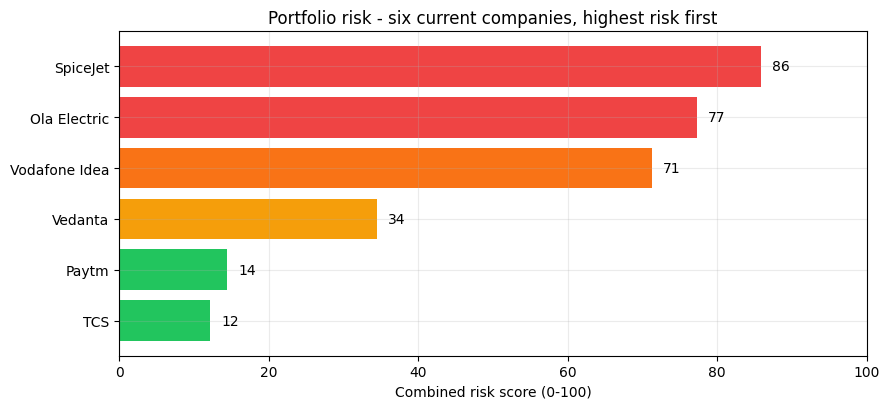

In [5]:

scorer = LoughranMcDonaldScorer()  # deterministic for reproducibility
recs = []
for rec, prior, _ in ROSTER:
    fin = score_company(rec, prior=prior)
    dig = pulse_as_of(rec.company, DEFAULT_AS_OF[rec.company], scorer)
    c = fuse(fin, dig)
    recs.append((rec.company, c.combined_score, c.financial_score, c.digital_score, c.band))
port = pd.DataFrame(recs, columns=["company", "combined", "financial", "digital", "band"]).sort_values("combined", ascending=False)
print(port.to_string(index=False))

cmap = {"Healthy": GOOD, "Watch": WATCH, "Elevated Risk": ELEV, "Critical": BAD}
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.barh(port["company"][::-1], port["combined"][::-1],
        color=[cmap[b] for b in port["band"][::-1]])
ax.set_xlabel("Combined risk score (0-100)"); ax.set_xlim(0, 100)
ax.set_title("Portfolio risk - six current companies, highest risk first")
for i, v in enumerate(port["combined"][::-1]):
    ax.text(v + 1.5, i, f"{v:.0f}", va="center", fontsize=10)
plt.tight_layout(); plt.show()

## 7. Explainability - in business language

The model's drivers, renamed from cryptic `AttrN` variables to what a credit analyst
reads. This is the global picture; the app shows a per-company Altman decomposition that
sums exactly to the displayed score.

                                Driver      Category  Mean impact
Operating Expenses / Total Liabilities    Efficiency      1.04858
               Interest Coverage Ratio      Solvency      0.73385
    3-Year Gross Profit / Total Assets Profitability      0.56188
           Sales Growth (year on year)        Growth      0.43336
                   Cost to Sales Ratio    Efficiency      0.43155
                     Cash Gross Margin Profitability      0.29348
       Company Size (log total assets)          Size      0.28101
                      Return on Assets Profitability      0.26981
      Retained Earnings / Total Assets Profitability      0.26905
       Operating Profit / Total Assets Profitability      0.20464
               Reserves / Total Assets      Solvency      0.19477
Debt to Annualised Operating Cash Flow      Solvency      0.18553


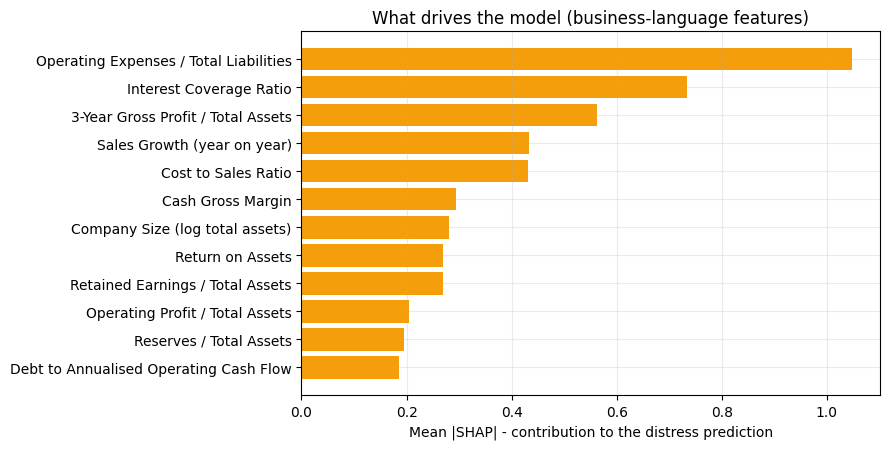

In [6]:

est, rep, feats = fit_calibrated(df, feature_set="screener")
gi = global_importance(est, df[feats], feats, top_n=12)
print(gi.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4.6))
ax.barh(gi["Driver"][::-1], gi["Mean impact"][::-1], color=AMBER)
ax.set_xlabel("Mean |SHAP| - contribution to the distress prediction")
ax.set_title("What drives the model (business-language features)")
plt.tight_layout(); plt.show()

---
### Summary

- Accuracy is meaningless at a 3.9% base rate; we evaluate on **PR-AUC** (0.80, 20x random).
- The model **beats the Altman benchmark ~11x on precision** at matched recall.
- We **dropped SMOTE** because the ablation said to.
- The GBM **does not transfer cross-border**, so serving is **Altman-anchored** - validated
  on six current companies, each in its expected band.
- Explainability is in **business language**, and the report/UI decomposition is exact.

Full rationale is in `docs/`.